##  **Détection DDoS : Un Système de Détection Multiclasse et Multidimensionnel avec Divers Modèles de Machine Learning**

---

###  **Aperçu du Projet**

Ce projet vise à construire un système capable de **détecter et classifier** les attaques **DDoS (Déni de Service Distribué)** en utilisant le jeu de données **CICDDoS2019**. L'objectif est de développer un modèle de **classification multiclasse** capable d'identifier différents types d'attaques DDoS à partir du trafic réseau normal. Le jeu de données comprend plusieurs types d'attaques ayant des caractéristiques de trafic réseau différentes, ce qui en fait un problème complexe pour la détection DDoS.

---

###  **Description du Jeu de Données**

Le jeu de données **CICDDoS2019**, fourni par l'Institut Canadien pour la Cybersécurité (CIC), contient des données de trafic réseau représentant plusieurs types d'attaques DDoS ainsi que du trafic bénin (non-attaque). Le jeu de données comporte plusieurs attributs comme la taille des paquets, les adresses IP source/destination et les types de protocoles. La variable cible est composée de différentes étiquettes d'attaques :

| Étiquette | Description |
|-----------|-------------|
| **Syn** | Attaque par inondation SYN |
| **Benign** | Trafic normal (non-attaque) |
| **UDP** | Attaque par inondation UDP générique |
| **MSSQL** | Attaque DDoS spécifique à MSSQL |
| **NetBIOS** | Attaque DDoS liée à NetBIOS |
| **LDAP** | Attaque basée sur le protocole LDAP |

---

###  **Aperçu du Processus**

####  **Collecte et Prétraitement des Données**

1. **Collecte des Chemins des Données** :
   - Les chemins des ensembles d'entraînement et de test sont collectés en parcourant les dossiers.
   - On s'assure que seuls les ensembles de données avec des noms correspondants sont utilisés pour l'entraînement et le test.

2. **Traitement des Données** :
   - **Mappage des Colonnes** : On mappe les noms de colonnes entre les ensembles d'entraînement et de test pour garantir leur cohérence. Les noms de colonnes dans l'ensemble de test sont renommés pour correspondre à ceux de l'ensemble d'entraînement.
   - **Gestion des Valeurs Nulles et Doublons** : On vérifie les valeurs nulles ou les doublons. Aucune valeur nulle n'est trouvée et les doublons sont supprimés.
   - **Suppression des Colonnes à Valeur Unique** : Les colonnes avec une seule valeur unique sont supprimées car elles n'apportent pas d'information utile.
   - **Suppression des Colonnes Fortement Corrélées** : Les colonnes avec un coefficient de corrélation ≥ 0,8 sont supprimées pour réduire la multicolinéarité et améliorer les performances du modèle.

---

###  **Analyse Exploratoire des Données (EDA)**

Plusieurs visualisations clés ont été réalisées pour comprendre le jeu de données :


- **Distribution de la Durée des Flux** :
   - Analyse de la durée des flux pour le trafic DDoS et normal.
- **Longueur Moyenne des Paquets par Protocole et par Attaque** :
   - Exploration de la longueur moyenne des paquets par type de protocole et par type d'attaque.
- **Distribution des Flags par Type d'Attaque** :
   - Distribution des différents types de flags par type d'attaque.
- **Distribution des Demandes par Protocole** :
   - Nombre de requêtes provenant de différents protocoles.
- **Matrice de Corrélation** :
   - Heatmap pour visualiser la matrice de corrélation et identifier les relations entre les caractéristiques.

---

###  **Prétraitement des Données et Ingénierie des Caractéristiques**

- **Division Entraînement/Test** :
   - Le jeu de données est divisé en ensembles d'entraînement, de validation et de test pour assurer une évaluation correcte du modèle.
- **Encodage des Caractéristiques** :
   - La colonne cible est encodée à l'aide de **LabelEncoder** pour convertir les étiquettes catégorielles en valeurs numériques.
- **Mise à l'Échelle des Caractéristiques** :
   - On applique la **Normalisation Min-Max** pour mettre les caractéristiques à l'échelle, améliorant ainsi les performances des algorithmes basés sur la distance.

---

###  **Entraînement et Évaluation du Modèle**

- **Sélection du Modèle** :
   - Plusieurs modèles sont entraînés et évalués pour la classification multiclasse, notamment :
     - **Forêt Aléatoire (Random Forest)**
     - **Extra Trees Classifier**
     - **XGBoost**

- **Évaluation du Modèle** :
   - On évalue les modèles à l'aide de diverses métriques comme la **précision (accuracy)**, la **précision (precision)**, le **rappel (recall)**, le **score F1** et l'**AUC ROC**.
   - Les courbes ROC sont tracées pour comparer les performances de chaque modèle à travers les différentes classes.
   - Un tableau des scores des modèles est créé et affiché pour faciliter la comparaison.

---

###  **Visualisation des Résultats**

- **Comparaison des Modèles** :
   - On trace le **score de précision (accuracy)** pour chaque modèle afin de comparer visuellement leurs performances.
   - Les courbes ROC pour tous les modèles sont tracées pour analyser leur capacité de classification, en particulier pour les tâches de classification multiclasse.

---



## 📚 Importation des Bibliothèques

In [2]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve


from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Métriques
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')
import os, gc, warnings
import pandas as pd
import numpy as np
import kagglehub
import gc
import warnings
from tqdm import tqdm

### COLLECTE + NETTOYAGE + SOUS-ECHANTILLONNAGE

SAMPLE_SIZE = 150000
RANDOM_SEED = 42

LABEL_MAPPING = {
    'DrDoS_DNS': 'DNS', 'DrDoS_LDAP': 'LDAP', 'DrDoS_MSSQL': 'MSSQL',
    'DrDoS_NTP': 'NTP', 'DrDoS_NetBIOS': 'NetBIOS', 'DrDoS_SNMP': 'SNMP',
    'DrDoS_SSDP': 'SSDP', 'DrDoS_UDP': 'UDP', 'Syn': 'Syn',
    'TFTP': 'TFTP', 'UDPLag': 'UDPLag', 'UDP-lag': 'UDPLag',
    'Portmap': 'Portmap', 'BENIGN': 'BENIGN', 'Benign': 'BENIGN'
}

CLASSES_EXCLURE = ['WebDDoS','Portmap']

DROP_COLS = [
    "Unnamed: 0", "Flow ID", "Source IP", "Destination IP",
    "Source Port", "Destination Port", "Timestamp", "SimillarHTTP",
    "Fwd Header Length.1", "Inbound", "Flow ID.1", "Label.1"
]

# les fichiers a charger
FICHIERS = [
    'DrDoS_DNS.csv', 'DrDoS_LDAP.csv', 'DrDoS_MSSQL.csv',
    'DrDoS_NTP.csv', 'DrDoS_NetBIOS.csv', 'DrDoS_SNMP.csv',
    'DrDoS_SSDP.csv', 'DrDoS_UDP.csv', 'Syn.csv',
    'TFTP.csv', 'UDPLag.csv', 'LDAP.csv', 'MSSQL.csv',
    'NetBIOS.csv', 'Portmap.csv', 'UDP.csv', 'UDPLag.csv'
]

CLASSES = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS',
           'SNMP', 'SSDP', 'UDP', 'Syn', 'TFTP', 'UDPLag']

print("\nTelechargement du dataset...")
path = kagglehub.dataset_download("rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files")
print("Dataset: " + path)

# LOCALISATION DES FICHIERS
fichiers = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f in FICHIERS:
            fichiers.append({'nom': f, 'chemin': os.path.join(root, f)})

print(str(len(fichiers)) + " fichiers trouves")

# COLLECTE + NETTOYAGE + SOUS-ECHANTILLONNAGE
reservoir = {cls: [] for cls in CLASSES}
compteurs = {cls: 0 for cls in CLASSES}
total = sum([SAMPLE_SIZE for _ in CLASSES])

pbar = tqdm(total=total, desc="Collecte", unit="echantillons")

for info in fichiers:
    try:
        for chunk in pd.read_csv(info['chemin'], chunksize=100000, low_memory=False):
            chunk.columns = chunk.columns.str.strip()

            if 'Label' not in chunk.columns:
                continue

            #  Suppression colonnes
            chunk = chunk.drop(columns=[c for c in DROP_COLS if c in chunk.columns], errors='ignore')

            #  Mapping labels
            chunk['Label'] = chunk['Label'].astype(str).str.strip().replace(LABEL_MAPPING)
            chunk = chunk[~chunk['Label'].isin(CLASSES_EXCLURE)]

            #  Nettoyage
            chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna().drop_duplicates()

            if chunk.empty:
                continue

            # Sous-echantillonnage
            for cls in CLASSES:
                if compteurs[cls] >= SAMPLE_SIZE:
                    continue

                sous = chunk[chunk['Label'] == cls]
                n = min(SAMPLE_SIZE - compteurs[cls], len(sous))

                if n > 0:
                    echantillon = sous.sample(n=n, random_state=RANDOM_SEED)
                    reservoir[cls].append(echantillon)
                    compteurs[cls] += n
                    pbar.update(n)

            del chunk
            gc.collect()

    except Exception as e:
        print("Erreur: " + str(e))
        continue

pbar.close()

frames = [pd.concat(v, ignore_index=True) for v in reservoir.values() if v]
df_final = pd.concat(frames, ignore_index=True)
df_final = df_final.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
df_final.to_csv('cicddos2019_150k.csv', index=False)


# Chargement du dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df  = pd.read_csv("/content/drive/MyDrive/DDoS2019/CICDDoS2019.csv")

Mounted at /content/drive


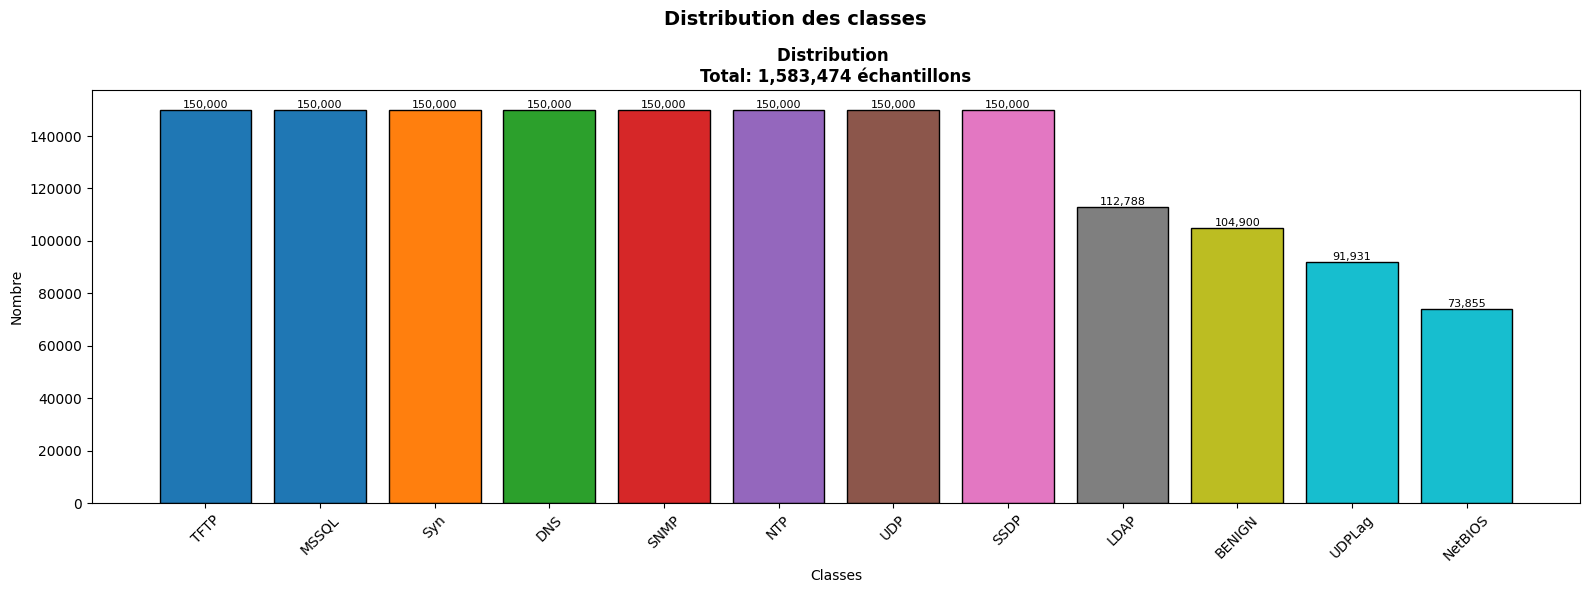

In [4]:
# 2. Créer les graphiques
fig, axes = plt.subplots(1, 1, figsize=(16, 6))

# Train
train_counts = df['Label'].value_counts()
axes.bar(train_counts.index, train_counts.values,
         color=plt.cm.tab10(np.linspace(0, 1, len(train_counts))),
         edgecolor='black')
axes.set_title(f'Distribution \nTotal: {len(df):,} échantillons', fontsize=12, fontweight='bold')
axes.set_xlabel('Classes', fontsize=10)
axes.set_ylabel('Nombre', fontsize=10)
axes.tick_params(axis='x', rotation=45)
for i, (label, count) in enumerate(train_counts.items()):
    axes.text(i, count + 100, f'{count:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribution des classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# taille du fichier
df.shape

(1583474, 78)

In [28]:
# appercu du fichier
df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,9002080,8,0,4128.0,0.0,516.0,516.0,516.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,TFTP
1,6,48,2,0,1174.0,0.0,587.0,587.0,587.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,MSSQL
2,6,32226125,6,0,36.0,0.0,6.0,6.0,6.0,0.0,...,20,3.0,0.0,3.0,3.0,16113060.5,5.841253e+06,20243450.0,11982671.0,Syn
3,17,46,2,0,1274.0,0.0,637.0,637.0,637.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,DNS
4,17,2,2,0,2928.0,0.0,1464.0,1464.0,1464.0,0.0,...,317,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,SNMP


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1583474 entries, 0 to 1583473
Data columns (total 78 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Protocol                  1583474 non-null  int64  
 1   Flow Duration             1583474 non-null  int64  
 2   Total Fwd Packets         1583474 non-null  int64  
 3   Total Backward Packets    1583474 non-null  int64  
 4   Fwd Packets Length Total  1583474 non-null  float64
 5   Bwd Packets Length Total  1583474 non-null  float64
 6   Fwd Packet Length Max     1583474 non-null  float64
 7   Fwd Packet Length Min     1583474 non-null  float64
 8   Fwd Packet Length Mean    1583474 non-null  float64
 9   Fwd Packet Length Std     1583474 non-null  float64
 10  Bwd Packet Length Max     1583474 non-null  float64
 11  Bwd Packet Length Min     1583474 non-null  float64
 12  Bwd Packet Length Mean    1583474 non-null  float64
 13  Bwd Packet Length Std     1

## Data Preprocessing

In [7]:
# Afficher les colonnes avec une seule valeur unique
for i in df.columns:
    if df[i].nunique() == 1:
        print(i)

Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
FIN Flag Count
PSH Flag Count
ECE Flag Count
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd Avg Bulk Rate


In [8]:
# Trouver les colonnes avec une seule valeur unique
colonnes_valeur_unique = [col for col in df.columns if df[col].nunique() == 1]
print(f"Colonnes avec une seule valeur : {colonnes_valeur_unique}")
#Supprimer les colonnes à valeur unique
df = df.drop(columns=colonnes_valeur_unique)


Colonnes avec une seule valeur : ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


#### Identifier les colonnes catégorielles, les colonnes numériques

In [9]:
SEUIL = 10

cat_cols = ([col for col in df.columns if df[col].dtypes == "O"] +
            [col for col in df.columns if df[col].nunique() < SEUIL and df[col].dtypes != "O"])

num_cols = [col for col in df.columns if df[col].dtypes != "O" and df[col].nunique() >= SEUIL]

print(f"Catégorielles : {len(cat_cols)}")
print(f"Numériques   : {len(num_cols)}")

Catégorielles : 8
Numériques   : 58


### Gestion des instances incoherentes

# valeurs infinie

In [10]:
# analyse des valeurs infinies
np.isinf(df.select_dtypes(include=np.number)).values.sum()

np.int64(0)

### valeurs manquantes

In [11]:
# Nombre total de valeurs manquantes
df.isnull().sum().sum()


np.int64(0)

### Lignes dupliquées

In [12]:
print(f" Nombre de lignes dupliquées : {df.duplicated().sum()}")

 Nombre de lignes dupliquées : 448600


In [13]:
# Supprimer les lignes dupliquées
df = df.drop_duplicates()

# Exploratory Data Analysis (EDA)



 Statistiques de Label :
Label
NTP        149383
TFTP       145411
SSDP       134134
UDP        133391
Syn        132919
BENIGN      95368
UDPLag      89080
MSSQL       71931
DNS         63335
SNMP        58263
LDAP        36842
NetBIOS     24817
Name: count, dtype: int64

Pourcentage :
Label
NTP        13.162959
TFTP       12.812964
SSDP       11.819286
UDP        11.753816
Syn        11.712225
BENIGN      8.403400
UDPLag      7.849330
MSSQL       6.338237
DNS         5.580796
SNMP        5.133874
LDAP        3.246352
NetBIOS     2.186763
Name: proportion, dtype: float64


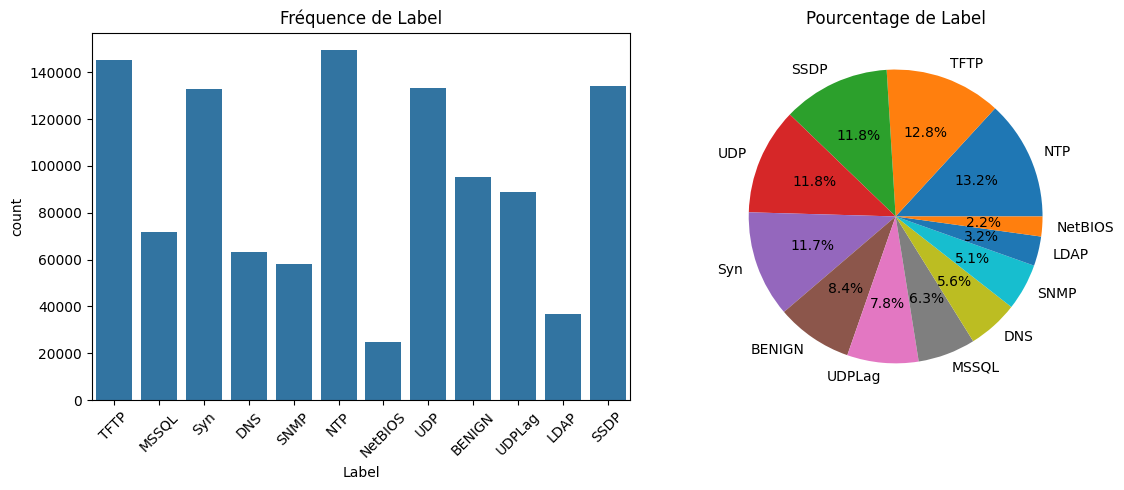

In [14]:
def analyser_colonne_cat(donnees, colonne):

    # Afficher les statistiques
    print(f"\n Statistiques de {colonne} :")
    print(donnees[colonne].value_counts())
    print("\nPourcentage :")
    print(donnees[colonne].value_counts(normalize=True) * 100)

    # Afficher les graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Diagramme à barres
    sns.countplot(x=colonne, data=donnees, ax=axes[0])
    axes[0].set_title(f'Fréquence de {colonne}')
    axes[0].tick_params(axis='x', rotation=45)

    # Diagramme circulaire
    valeurs = donnees[colonne].value_counts()
    axes[1].pie(valeurs, labels=valeurs.index, autopct='%1.1f%%')
    axes[1].set_title(f'Pourcentage de {colonne}')

    plt.tight_layout()
    plt.show()

analyser_colonne_cat(df, 'Label')

# Analyser toutes les colonnes catégorielles
#for col in cat_cols:
    #analyser_colonne_cat(train_df, col)

for col in train_df.columns:
    if col != 'Label' and train_df[col].dtype in ['int64', 'float32']:
        print(f'ANALYSE DE {col}')
        print(train_df.groupby('Label')[col].mean().sort_values(ascending=False))

In [15]:
def plot_boxplot(variable, df):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Label", y=variable, data=df)
    plt.yscale('log')
    plt.title(f"Distribution de {variable}", fontsize=14, fontweight='bold')
    plt.xlabel("Type de trafic")
    plt.ylabel(variable)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

###  Flow Duration = Le temps total pendant lequel un flux réseau a été actif (du premier paquet au dernier paquet)

In [16]:
stats_secondes = df.groupby('Label')['Flow Duration'].describe()
stats_secondes

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,95368.0,1.205597e+07,3.254189e+07,1.0,20597.00,23095.5,225810.50,119998742.0
DNS,63335.0,8.360747e+04,1.686343e+06,1.0,2.00,44.0,239.00,119999997.0
LDAP,36842.0,6.739160e+04,1.443746e+06,1.0,2.00,39.0,66.00,119114825.0
MSSQL,71931.0,4.167492e+04,5.631607e+05,1.0,1.00,2.0,48.00,65467052.0
NTP,149383.0,7.380195e+04,1.328240e+06,1.0,489.00,1402.0,7733.50,119776074.0
NetBIOS,24817.0,1.125087e+07,1.894471e+07,1.0,3.00,57.0,40820776.00,119708369.0
SNMP,58263.0,1.440284e+05,3.460187e+06,1.0,1.00,2.0,42.00,119999986.0
SSDP,134134.0,1.950553e+05,1.351640e+06,1.0,106537.00,108937.0,215745.75,119714230.0
Syn,132919.0,4.058290e+07,1.869584e+07,1.0,31875274.50,42635738.0,56041994.00,110709420.0


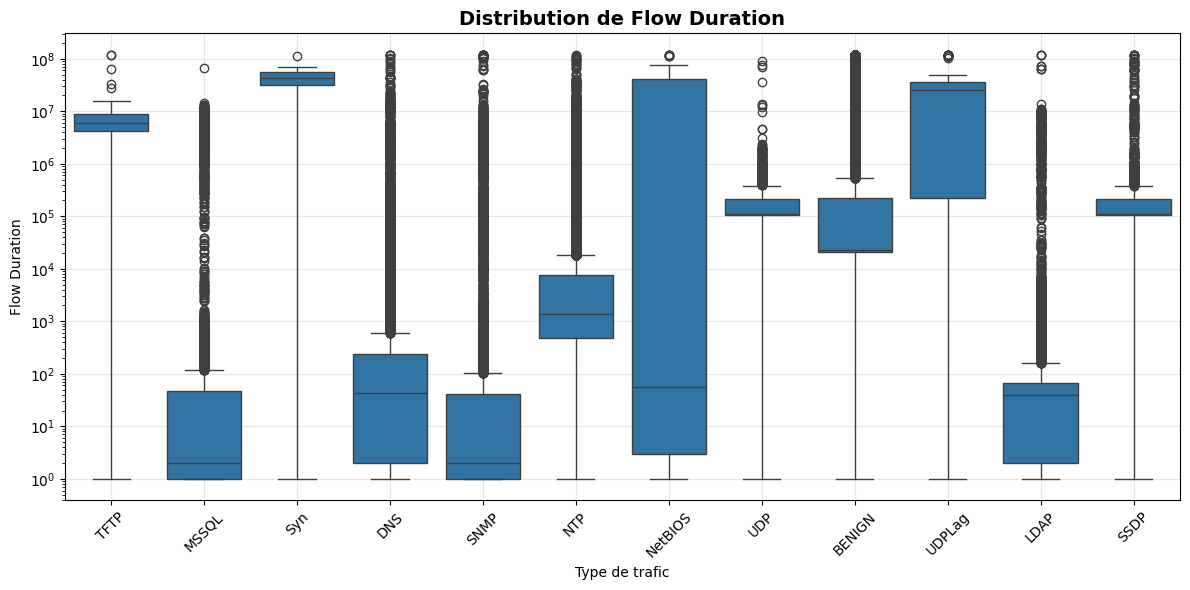

In [17]:
plot_boxplot('Flow Duration', df)

# Fwd Packets/s : C'est le rythme d'envoi des paquets, combien de paquets partent vers la victime chaque seconde.

In [18]:
FwdPackets = df.groupby('Label')['Fwd Packets/s'].describe()
FwdPackets


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,95368.0,6.550632e+04,312288.386493,0.008480,18.118896,94.073377,9.810293e+01,3000000.0
DNS,63335.0,6.538214e+05,813119.813298,0.010049,8968.609865,45454.545455,1.000000e+06,2000000.0
LDAP,36842.0,6.563575e+05,817114.531278,0.055659,35398.230088,52631.578947,1.000000e+06,2000000.0
MSSQL,71931.0,1.071983e+06,912786.173795,0.061099,42553.191489,1000000.000000,2.000000e+06,4000000.0
NTP,149383.0,6.742751e+04,132395.363610,0.030518,7853.264236,27272.727273,9.433208e+04,4000000.0
NetBIOS,24817.0,4.687230e+05,766525.136124,0.052723,0.098356,40816.326531,1.000000e+06,4000000.0
SNMP,58263.0,9.993783e+05,787721.530193,0.053434,48780.487805,1000000.000000,2.000000e+06,3000000.0
SSDP,134134.0,5.485244e+04,284718.101150,0.038253,27.813962,36.735837,3.759893e+01,2000000.0
Syn,132919.0,1.789302e+03,24648.531545,0.061198,0.176250,0.204991,2.471738e-01,2000000.0


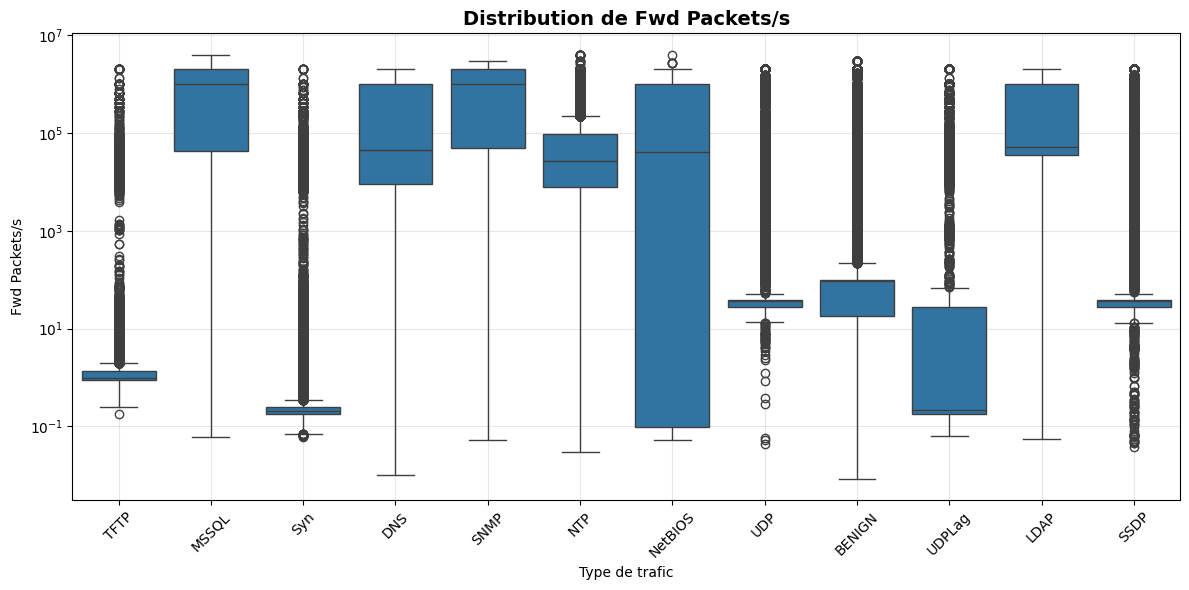

In [19]:
plot_boxplot('Fwd Packets/s', df)


### Analyse des requêtes provenant de différents protocoles

Tableau croisé : Protocole vs Attaque
Protocol      6       17
Label                   
BENIGN     59515   35853
DNS            0   63335
LDAP           0   36842
MSSQL      71931       0
NTP            0  149383
NetBIOS        0   24817
SNMP           0   58263
SSDP      134134       0
Syn       132919       0
TFTP           0  145411
UDP            0  133391
UDPLag         0   89080


<Figure size 1200x600 with 0 Axes>

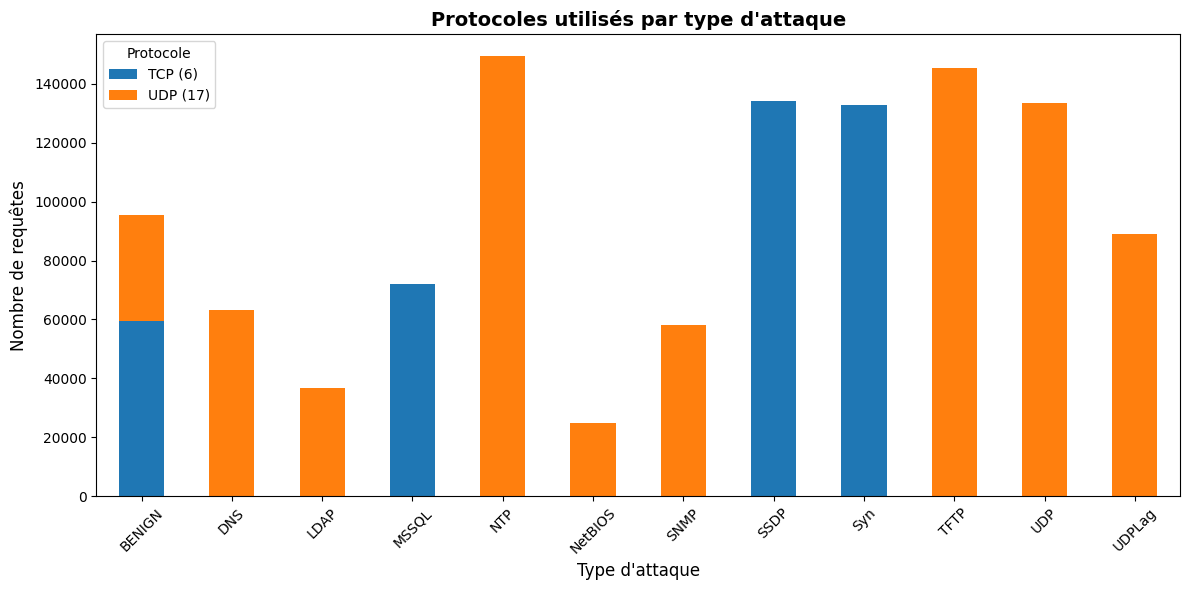

In [20]:
# Créer un tableau
tableau_croise = pd.crosstab(df['Label'], df['Protocol'])
print("Tableau croisé : Protocole vs Attaque")
print(tableau_croise)
plt.figure(figsize=(12, 6))

# Créer un graphique à barres
tableau_croise.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title("Protocoles utilisés par type d'attaque", fontsize=14, fontweight='bold')
plt.xlabel("Type d'attaque", fontsize=12)
plt.ylabel("Nombre de requêtes", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Protocole", labels=['TCP (6)', 'UDP (17)'])
plt.tight_layout()
plt.show()


In [21]:
df['Label'] = df['Label'].apply(lambda x:
    'BENIGN' if x=='BENIGN'
    else 'ATTACK_REFLECTION' if x in ['DNS','LDAP','NetBIOS','SNMP','SSDP','MSSQL','NTP','TFTP']
    else 'ATTACK_EXPLOITATION'
)
print("Colonnes conservées :", df.columns.tolist())

Colonnes conservées : ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow F

In [22]:
# Afficher toutes les colonnes disponibles
print("Colonnes disponibles :")
print(df.columns.tolist())

# Afficher les types de données
print("\nTypes de données :")
print(df.dtypes)

Colonnes disponibles :
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow 

In [23]:
for col in num_cols:
    df[col] = df[col].astype('float32')


for col in cat_cols:
    df[col] = df[col].astype('category')

### Sélection des Caractéristiques  : Suppresion de variable fortement correler


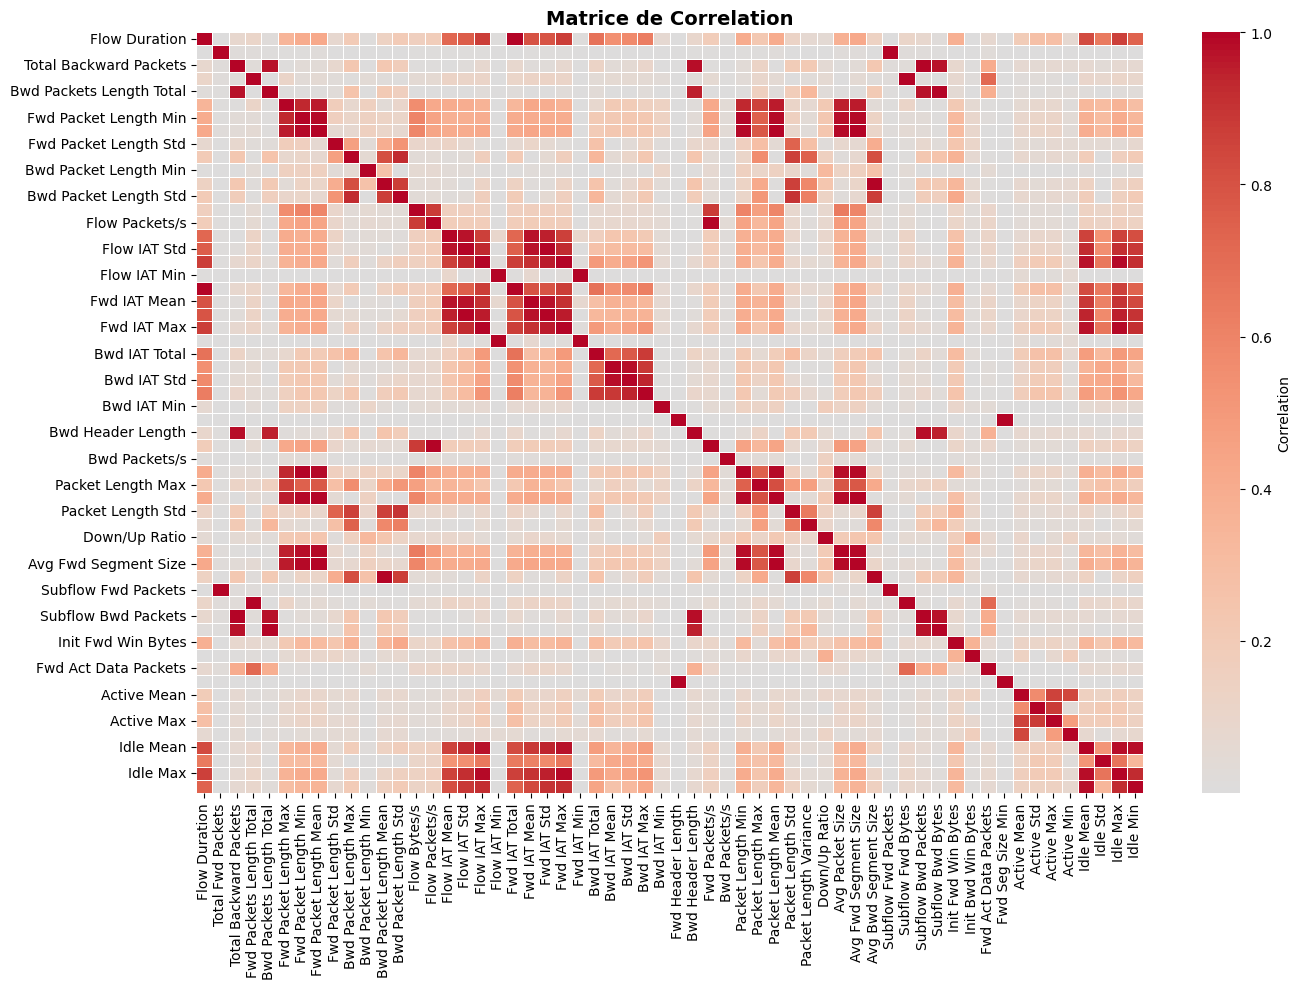

Colonnes fortement correlees (> 0.8): 34
['Bwd Packets Length Total', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Packets/s', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd Header Length', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Fwd Seg Size Min', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']


In [24]:
#Selectionner les colonnes numeriques
colonnes_numeriques = df.select_dtypes(include=[np.number])

#  Calculer la matrice de correlation
matrice_correlation = colonnes_numeriques.corr().abs()

# Masque pour le triangle superieur
masque = np.triu(np.ones(matrice_correlation.shape), k=1).astype(bool)

# 4. Afficher la heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(matrice_correlation,
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
plt.title('Matrice de Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identifier les correlations elevees
triangle_superieur = matrice_correlation.where(masque)

colonnes_fortement_correlees = [
    col for col in triangle_superieur.columns
    if any(triangle_superieur[col] > 0.8)
]

print("Colonnes fortement correlees (> 0.8): " + str(len(colonnes_fortement_correlees)))
print(colonnes_fortement_correlees)

In [25]:
# suppression des colonnes fortement corrélées
df.drop(colonnes_fortement_correlees, axis=1, inplace=True)


In [26]:
df.shape

(1134874, 32)

### Division en ensembles d'entraînement, validation et test


In [27]:
X_train, X_test, y_train, y_test = train_test_split(df.drop("Label", axis=1), df["Label"], test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.125,
    random_state=42,
    stratify=y_train
)

print(f"    X_train : {X_train.shape}")
print(f"    X_val   : {X_val.shape}")
print(f"    X_test  : {X_test.shape}")

    X_train : (794411, 31)
    X_val   : (113488, 31)
    X_test  : (226975, 31)


In [28]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 794411 entries, 56468 to 459804
Data columns (total 31 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  794411 non-null  category
 1   Flow Duration             794411 non-null  float32 
 2   Total Fwd Packets         794411 non-null  float32 
 3   Total Backward Packets    794411 non-null  float32 
 4   Fwd Packets Length Total  794411 non-null  float32 
 5   Fwd Packet Length Max     794411 non-null  float32 
 6   Fwd Packet Length Std     794411 non-null  float32 
 7   Bwd Packet Length Max     794411 non-null  float32 
 8   Bwd Packet Length Min     794411 non-null  float32 
 9   Flow Bytes/s              794411 non-null  float32 
 10  Flow IAT Mean             794411 non-null  float32 
 11  Flow IAT Min              794411 non-null  float32 
 12  Bwd IAT Total             794411 non-null  float32 
 13  Bwd IAT Mean              7944

In [29]:
print(pd.Series(y_train).value_counts())

Label
ATTACK_REFLECTION      478621
ATTACK_EXPLOITATION    248906
BENIGN                  66884
Name: count, dtype: int64


In [30]:
from sklearn.preprocessing import LabelEncoder
import joblib

#  Encoder la cible
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)
y_val = le_target.transform(y_val)
y_test = le_target.transform(y_test)

print(f" Classes: {le_target.classes_}")
print(f" Mapping: {dict(enumerate(le_target.classes_))}")
#  Sauvegarder
joblib.dump(le_target, '/content/drive/MyDrive/DDoS2019/label_encoder_ddos.pkl')

 Classes: ['ATTACK_EXPLOITATION' 'ATTACK_REFLECTION' 'BENIGN']
 Mapping: {0: 'ATTACK_EXPLOITATION', 1: 'ATTACK_REFLECTION', 2: 'BENIGN'}


['/content/drive/MyDrive/DDoS2019/label_encoder_ddos.pkl']

In [31]:
# Mise à l'échelle des caractéristiques
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

scaler = MinMaxScaler()
#scaler = StandardScaler()
#scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
joblib.dump(scaler, '/content/drive/MyDrive/DDoS2019/scaler_ddos.pkl')

['/content/drive/MyDrive/DDoS2019/scaler_ddos.pkl']


ENTRAÎNEMENT AVANT RANDOM UNDERSAMPLER

Modèle : Random Forest_avant_Reechantillonnage
Temps d'entraînement : 227.23 s

Performances :
   Précision Globale : 0.9884
   Précision         : 0.9884
   Rappel            : 0.9884
   F1-Score          : 0.9884
   ROC AUC           : 0.9991

Rapport de classification :
                     precision    recall  f1-score   support

ATTACK_EXPLOITATION       0.98      0.98      0.98     70926
  ATTACK_REFLECTION       0.99      0.99      0.99    137120
             BENIGN       1.00      1.00      1.00     18929

           accuracy                           0.99    226975
          macro avg       0.99      0.99      0.99    226975
       weighted avg       0.99      0.99      0.99    226975


Modèle : XGBoost_avant_Reechantillonnage
Temps d'entraînement : 41.15 s

Performances :
   Précision Globale : 0.9909
   Précision         : 0.9909
   Rappel            : 0.9909
   F1-Score          : 0.9909
   ROC AUC           : 0.9998

Rapport de clas

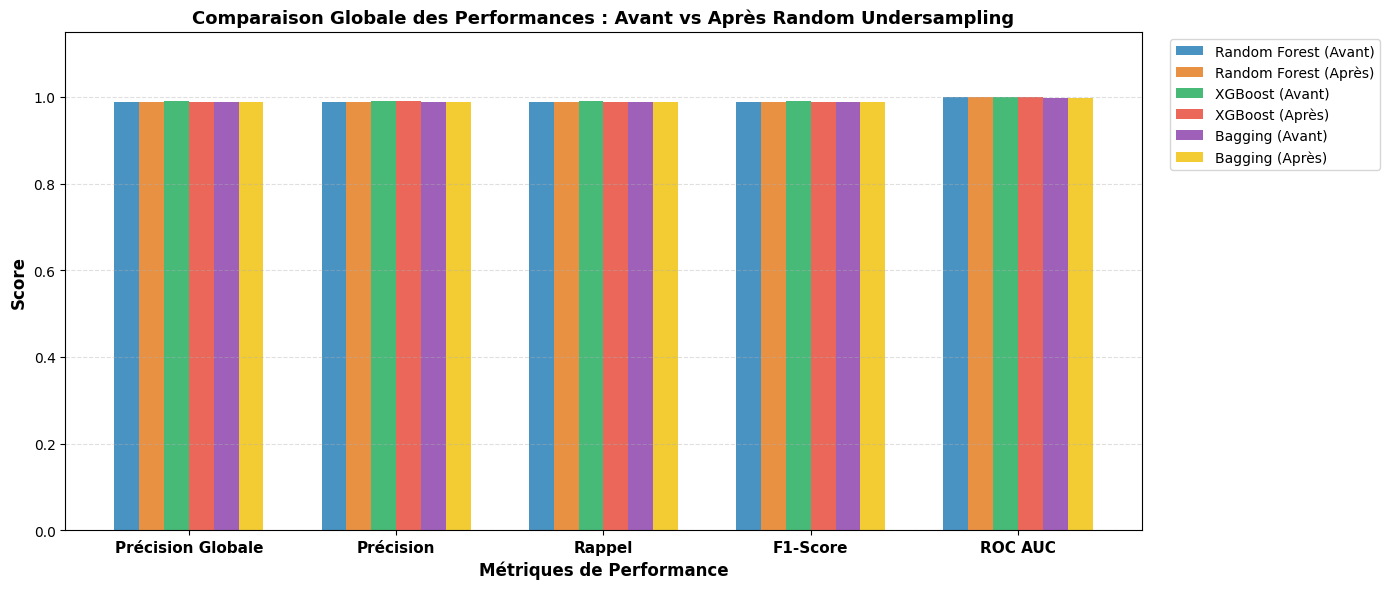

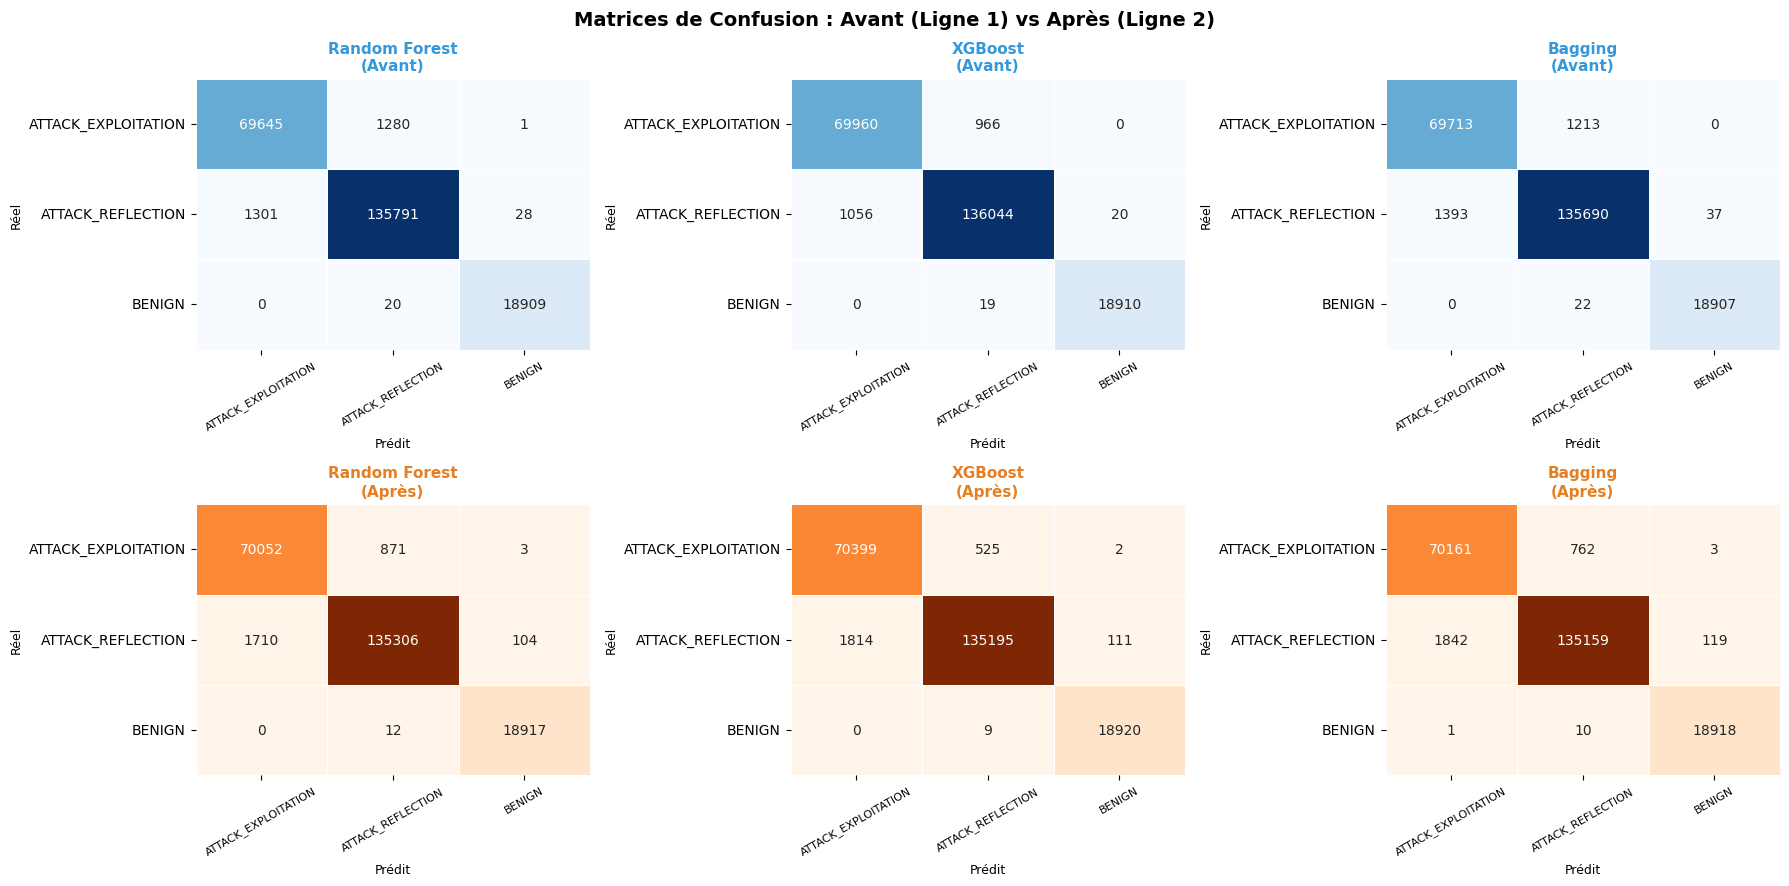


TABLEAU RÉCAPITULATIF DES PERFORMANCES

                                Modèle  Précision Globale  Précision   Rappel  F1-Score  ROC AUC  Temps (s)
Random Forest_avant_Reechantillonnage           0.988413   0.988413 0.988413  0.988413 0.999071     227.23
      XGBoost_avant_Reechantillonnage           0.990920   0.990923 0.990920  0.990921 0.999783      41.15
      Bagging_avant_Reechantillonnage           0.988259   0.988267 0.988259  0.988262 0.997373      96.78
Random Forest_apres_Reechantillonnage           0.988104   0.988168 0.988104  0.988118 0.999046      37.85
      XGBoost_apres_Reechantillonnage           0.989157   0.989278 0.989157  0.989177 0.999739      11.26
      Bagging_apres_Reechantillonnage           0.987941   0.988036 0.987941  0.987959 0.997464      20.47

Tableau exporté dans 'comparaison_undersampling_complet.csv'

MEILLEURS MODÈLES PAR PRÉCISION GLOBALE

Avant :
   Modèle : XGBoost_avant_Reechantillonnage
   Précision Globale : 0.9909
   F1-Score : 0.9909
  

In [41]:
import joblib
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler


def entrainer_modeles(X_train, y_train, X_test, y_test, noms_classes, suffixe=""):
    """
    Entraîne les modèles avec un suffixe pour différencier avant/après undersampling
    """
    # Définition des modèles avec suffixe
    modeles = {
        f'Random Forest{suffixe}': RandomForestClassifier(random_state=42),
        f'XGBoost{suffixe}': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
        f'Bagging{suffixe}': BaggingClassifier(estimator=DecisionTreeClassifier(),
                                                n_estimators=10, random_state=42)
    }

    resultats = {}
    resume = []
    matrices_confusion = {}
    rapports = {}

    for nom, modele in modeles.items():
        print(f"\n{'='*60}")
        print(f"Modèle : {nom}")
        print(f"{'='*60}")

        # Entraînement
        debut = time.time()
        modele.fit(X_train, y_train)
        duree = time.time() - debut
        print(f"Temps d'entraînement : {duree:.2f} s")

        # Prédictions
        y_pred = modele.predict(X_test)
        y_proba = modele.predict_proba(X_test)

        # Métriques
        precision_globale = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rappel = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # ROC AUC (multiclasse OVR)
        classes_uniques = np.unique(y_train)
        y_test_bin = label_binarize(y_test, classes=classes_uniques)

        if y_proba.shape[1] == len(classes_uniques):
            roc_auc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')
        else:
            roc_auc = 0.0
            print("Attention : Le nombre de classes dans y_proba ne correspond pas à y_train")

        # Rapport de classification
        rapport_dict = classification_report(y_test, y_pred, target_names=noms_classes,
                                            output_dict=True, zero_division=0)
        rapports[nom] = rapport_dict

        print(f"\nPerformances :")
        print(f"   Précision Globale : {precision_globale:.4f}")
        print(f"   Précision         : {precision:.4f}")
        print(f"   Rappel            : {rappel:.4f}")
        print(f"   F1-Score          : {f1:.4f}")
        print(f"   ROC AUC           : {roc_auc:.4f}")
        print("\nRapport de classification :")
        print(classification_report(y_test, y_pred, target_names=noms_classes, zero_division=0))

        # Stockage
        matrices_confusion[nom] = confusion_matrix(y_test, y_pred)

        resultats[nom] = {
            'precision_globale': precision_globale,
            'precision': precision,
            'rappel': rappel,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'temps_entrainement': duree,
            'modele': modele,
            'y_pred': y_pred,
            'y_proba': y_proba
        }

        resume.append({
            'Modèle': nom,
            'Précision Globale': precision_globale,
            'Précision': precision,
            'Rappel': rappel,
            'F1-Score': f1,
            'ROC AUC': roc_auc,
            'Temps (s)': round(duree, 2)
        })

    return resultats, resume, matrices_confusion, rapports


# Noms des classes
noms_classes = ['ATTACK_EXPLOITATION', 'ATTACK_REFLECTION', 'BENIGN']

# =====================================================
# 1. ENTRAÎNEMENT AVANT RANDOM UNDERSAMPLER
# =====================================================
print("\n" + "="*80)
print("ENTRAÎNEMENT AVANT RANDOM UNDERSAMPLER")
print("="*80)

resultats_avant, resume_avant, matrices_avant, rapports_avant = entrainer_modeles(
    X_train, y_train, X_test, y_test, noms_classes, suffixe="_avant_Reechantillonnage"
)

# =====================================================
# 2. APPLICATION DE RANDOM UNDERSAMPLER
# =====================================================
print("\n" + "="*80)
print("APPLICATION DE RANDOM UNDERSAMPLER")
print("="*80)

print("\nDistribution AVANT rééchantillonnage :")
print(pd.Series(y_train).value_counts().sort_index())

sous_echantillonneur = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = sous_echantillonneur.fit_resample(X_train, y_train)

print("\nDistribution APRÈS rééchantillonnage :")
print(pd.Series(y_train_rus).value_counts().sort_index())

# =====================================================
# 3. ENTRAÎNEMENT APRÈS RANDOM UNDERSAMPLER
# =====================================================
print("\n" + "="*80)
print("ENTRAÎNEMENT APRÈS RANDOM UNDERSAMPLER")
print("="*80)

resultats_apres, resume_apres, matrices_apres, rapports_apres = entrainer_modeles(
    X_train_rus, y_train_rus, X_test, y_test, noms_classes, suffixe="_apres_Reechantillonnage"
)

# =====================================================
# 4. TABLEAU DE COMPARAISON PAR CLASSE
# =====================================================
print("\n" + "="*80)
print("TABLEAU DE COMPARAISON PAR CLASSE")
print("="*80)

# Récupérer les rapports XGBoost
if 'XGBoost_avant_Reechantillonnage' in rapports_avant and 'XGBoost_apres_Reechantillonnage' in rapports_apres:
    rapport_xgb_avant = rapports_avant['XGBoost_avant_Reechantillonnage']
    rapport_xgb_apres = rapports_apres['XGBoost_apres_Reechantillonnage']

    donnees_tableau = []
    for classe in noms_classes:
        if classe in rapport_xgb_avant and classe in rapport_xgb_apres:
            ligne = {
                'Classe': classe,
                ('XGBoost (base)', 'Précision'): f"{rapport_xgb_avant[classe]['precision']:.3f}",
                ('XGBoost (base)', 'Rappel'): f"{rapport_xgb_avant[classe]['recall']:.3f}",
                ('XGBoost (base)', 'F1-score'): f"{rapport_xgb_avant[classe]['f1-score']:.3f}",
                ('XGBoost (base)', 'Support'): f"{int(rapport_xgb_avant[classe]['support']):,}".replace(',', ' '),
                ('XGBoost + UnderSampling', 'Précision'): f"{rapport_xgb_apres[classe]['precision']:.3f}",
                ('XGBoost + UnderSampling', 'Rappel'): f"{rapport_xgb_apres[classe]['recall']:.3f}",
                ('XGBoost + UnderSampling', 'F1-score'): f"{rapport_xgb_apres[classe]['f1-score']:.3f}",
                ('XGBoost + UnderSampling', 'Support'): f"{int(rapport_xgb_apres[classe]['support']):,}".replace(',', ' ')
            }
            donnees_tableau.append(ligne)

    if donnees_tableau:
        df_xgb_classe = pd.DataFrame(donnees_tableau)
        df_xgb_classe.set_index('Classe', inplace=True)
        df_xgb_classe.columns = pd.MultiIndex.from_tuples(df_xgb_classe.columns)

        print("\n", df_xgb_classe)
        df_xgb_classe.to_csv('comparaison_xgboost_par_classe.csv')
        print("\nTableau exporté dans 'comparaison_xgboost_par_classe.csv'")

# =====================================================
# 5. GRAPHIQUE DE COMPARAISON
# =====================================================
df_avant = pd.DataFrame(resume_avant)
df_apres = pd.DataFrame(resume_apres)

plt.figure(figsize=(14, 6))

metriques = ['Précision Globale', 'Précision', 'Rappel', 'F1-Score', 'ROC AUC']
modeles_propres = df_avant['Modèle'].str.replace('_avant_Reechantillonnage', '').str.replace('_apres_Reechantillonnage', '').unique()

x = np.arange(len(metriques))
largeur = 0.12
couleurs_avant = ['#2980b9', '#27ae60', '#8e44ad']
couleurs_apres = ['#e67e22', '#e74c3c', '#f1c40f']

for i, modele in enumerate(modeles_propres):
    lignes_avant = df_avant[df_avant['Modèle'].str.contains(modele.replace(' ', '|'))]
    lignes_apres = df_apres[df_apres['Modèle'].str.contains(modele.replace(' ', '|'))]

    if not lignes_avant.empty and not lignes_apres.empty:
        valeurs_avant = lignes_avant[metriques].values[0]
        valeurs_apres = lignes_apres[metriques].values[0]

        pos_avant = x + (2 * i - 2.5) * largeur
        pos_apres = x + (2 * i - 1.5) * largeur

        barres1 = plt.bar(pos_avant, valeurs_avant, largeur,
                         label=f'{modele} (Avant)',
                         color=couleurs_avant[i % len(couleurs_avant)], alpha=0.85)
        barres2 = plt.bar(pos_apres, valeurs_apres, largeur,
                         label=f'{modele} (Après)',
                         color=couleurs_apres[i % len(couleurs_apres)], alpha=0.85)

plt.xlabel('Métriques de Performance', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Comparaison Globale des Performances : Avant vs Après Random Undersampling',
          fontsize=13, fontweight='bold')
plt.xticks(x, metriques, fontsize=11, fontweight='bold')
plt.ylim(0, 1.15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# =====================================================
# 6. MATRICES DE CONFUSION
# =====================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Ligne 1 : Avant
for idx, (nom, matrice) in enumerate(matrices_avant.items()):
    ax = axes[0, idx]
    sns.heatmap(matrice, annot=True, fmt='d', cmap='Blues',
                xticklabels=noms_classes, yticklabels=noms_classes,
                ax=ax, linewidths=0.5, cbar=False)
    nom_affichage = nom.replace("_avant_Reechantillonnage", "")
    ax.set_title(f'{nom_affichage}\n(Avant)', fontsize=11, fontweight='bold', color='#3498db')
    ax.set_xlabel('Prédit', fontsize=9)
    ax.set_ylabel('Réel', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

# Ligne 2 : Après
for idx, (nom, matrice) in enumerate(matrices_apres.items()):
    ax = axes[1, idx]
    sns.heatmap(matrice, annot=True, fmt='d', cmap='Oranges',
                xticklabels=noms_classes, yticklabels=noms_classes,
                ax=ax, linewidths=0.5, cbar=False)
    nom_affichage = nom.replace("_apres_Reechantillonnage", "")
    ax.set_title(f'{nom_affichage}\n(Après)', fontsize=11, fontweight='bold', color='#e67e22')
    ax.set_xlabel('Prédit', fontsize=9)
    ax.set_ylabel('Réel', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle('Matrices de Confusion : Avant (Ligne 1) vs Après (Ligne 2)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================
# 7. TABLEAU RÉCAPITULATIF
# =====================================================
print("\n" + "="*80)
print("TABLEAU RÉCAPITULATIF DES PERFORMANCES")
print("="*80)

df_comparaison = pd.concat([df_avant, df_apres], ignore_index=True)
print("\n", df_comparaison.to_string(index=False))
df_comparaison.to_csv('comparaison_undersampling_complet.csv', index=False)
print("\nTableau exporté dans 'comparaison_undersampling_complet.csv'")

# =====================================================
# 8. MEILLEURS MODÈLES
# =====================================================
print("\n" + "="*80)
print("MEILLEURS MODÈLES PAR PRÉCISION GLOBALE")
print("="*80)

meilleur_avant = df_avant.loc[df_avant['Précision Globale'].idxmax()]
meilleur_apres = df_apres.loc[df_apres['Précision Globale'].idxmax()]

print(f"\nAvant :")
print(f"   Modèle : {meilleur_avant['Modèle']}")
print(f"   Précision Globale : {meilleur_avant['Précision Globale']:.4f}")
print(f"   F1-Score : {meilleur_avant['F1-Score']:.4f}")
print(f"   Temps : {meilleur_avant['Temps (s)']:.2f}s")

print(f"\nAprès :")
print(f"   Modèle : {meilleur_apres['Modèle']}")
print(f"   Précision Globale : {meilleur_apres['Précision Globale']:.4f}")
print(f"   F1-Score : {meilleur_apres['F1-Score']:.4f}")
print(f"   Temps : {meilleur_apres['Temps (s)']:.2f}s")

# =====================================================
# 9. SAUVEGARDE
# =====================================================
joblib.dump(resultats_avant[meilleur_avant['Modèle']]['modele'],
            'meilleur_modele_avant.pkl')
joblib.dump(resultats_apres[meilleur_apres['Modèle']]['modele'],
            'meilleur_modele_apres.pkl')

print("\nModèles sauvegardés :")
print("  - meilleur_modele_avant.pkl")
print("  - meilleur_modele_apres.pkl")

print("\n" + "="*80)
print("EXÉCUTION TERMINÉE")
print("="*80)

 Modèle : Random Forest
 Temps d'entraînement : 235.07 s

 Performances :
   Accuracy  : 0.9884
   Precision : 0.9884
   Recall    : 0.9884
   F1 Score  : 0.9884
   ROC AUC   : 0.9991

 Rapport de classification :
                     precision    recall  f1-score   support

ATTACK_EXPLOITATION       0.98      0.98      0.98     70926
  ATTACK_REFLECTION       0.99      0.99      0.99    137120
             BENIGN       1.00      1.00      1.00     18929

           accuracy                           0.99    226975
          macro avg       0.99      0.99      0.99    226975
       weighted avg       0.99      0.99      0.99    226975

 Modèle : XGBoost
 Temps d'entraînement : 40.26 s

 Performances :
   Accuracy  : 0.9909
   Precision : 0.9909
   Recall    : 0.9909
   F1 Score  : 0.9909
   ROC AUC   : 0.9998

 Rapport de classification :
                     precision    recall  f1-score   support

ATTACK_EXPLOITATION       0.99      0.99      0.99     70926
  ATTACK_REFLECTION       

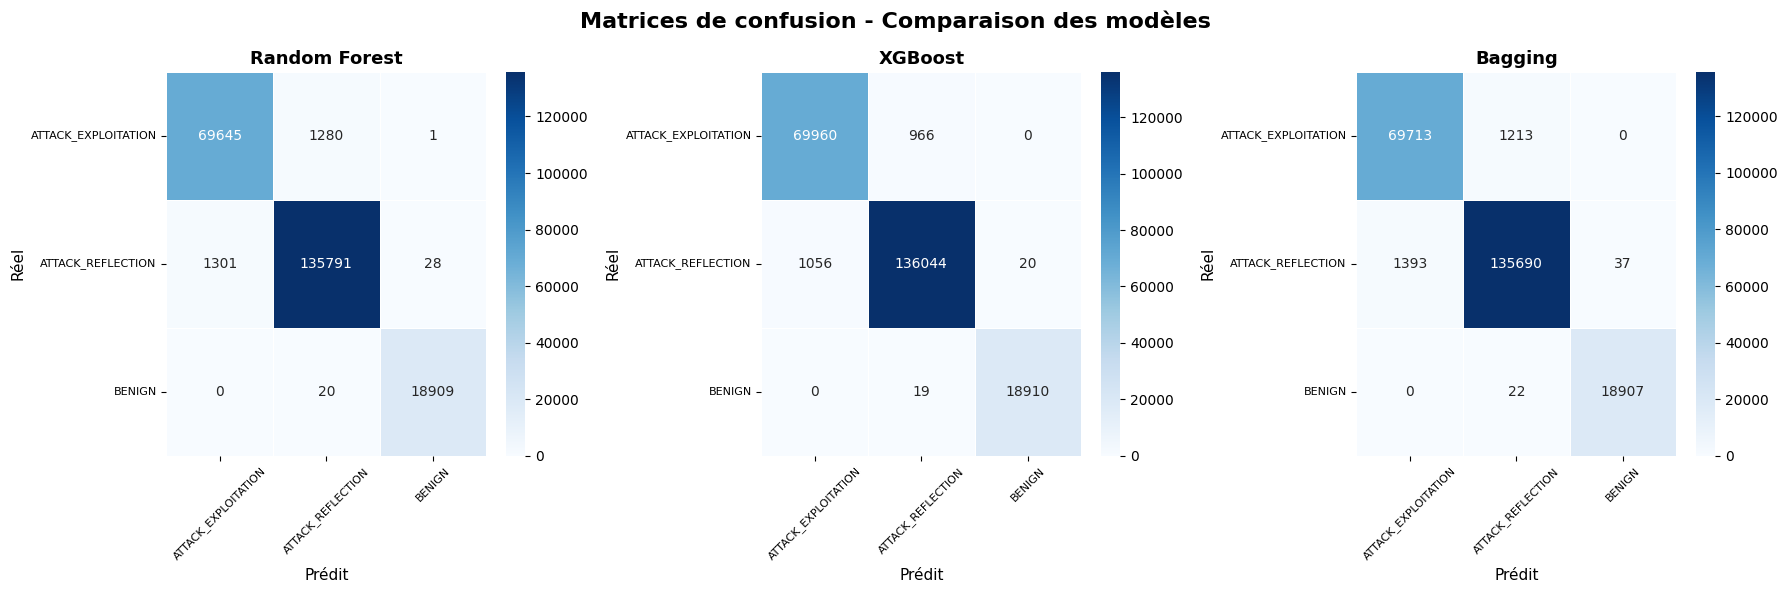

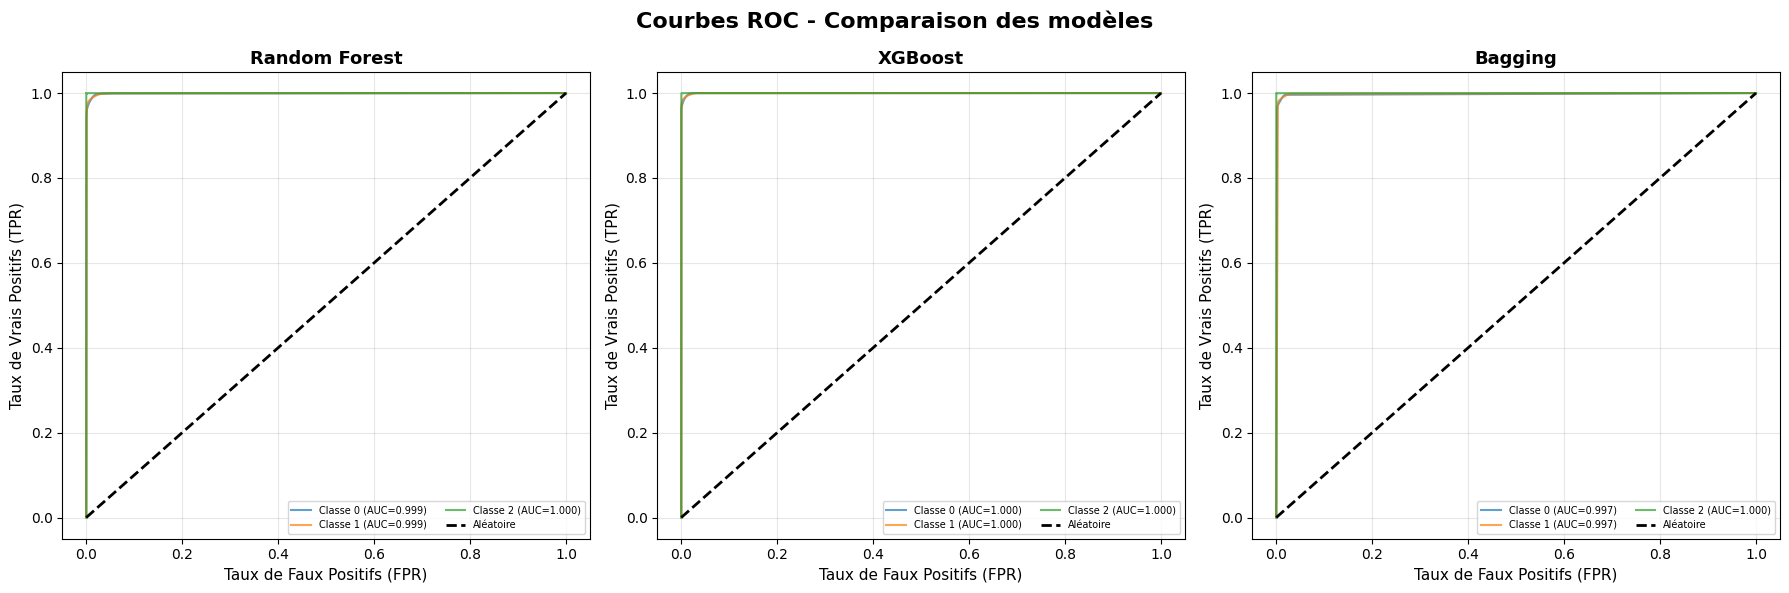

,Modèle,Accuracy,Precision,Recall,F1 Score,ROC AUC,Temps (s)
0,Random Forest,0.988413,0.988413,0.988413,0.988413,0.999071,235.070000
1,XGBoost,0.990920,0.990923,0.990920,0.990921,0.999783,40.260000
2,Bagging,0.988259,0.988267,0.988259,0.988262,0.997373,98.210000



 Classement par Accuracy :


In [56]:
import joblib
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from xgboost import XGBClassifier


def train_models(X_train, y_train, X_test, y_test, class_names):


    # Définition des modèles
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
        'Bagging': BaggingClassifier(estimator=DecisionTreeClassifier(),
                                     n_estimators=10, random_state=42)
    }

    results = {}
    summary = []

    # Dictionnaires pour stocker les données de visualisation
    confusion_matrices = {}
    probas = {}
    y_preds = {}

    # Entraînement et évaluation pour chaque modèle
    for name, model in models.items():
        print(f" Modèle : {name}")


        # Entraînement
        start = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - start
        print(f" Temps d'entraînement : {elapsed:.2f} s")

        # Prédictions
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        # Métriques
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # ROC AUC (multiclasse)
        n_classes = len(np.unique(y_train))
        y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
        roc_auc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')

        print(f"\n Performances :")
        print(f"   Accuracy  : {acc:.4f}")
        print(f"   Precision : {prec:.4f}")
        print(f"   Recall    : {rec:.4f}")
        print(f"   F1 Score  : {f1:.4f}")
        print(f"   ROC AUC   : {roc_auc:.4f}")
        print("\n Rapport de classification :")
        print(classification_report(y_test, y_pred, target_names=class_names))

        # Stockage pour les visualisations
        confusion_matrices[name] = confusion_matrix(y_test, y_pred)
        probas[name] = y_proba
        y_preds[name] = y_pred

        # Sauvegarde des résultats
        results[name] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'training_time': elapsed,
            'model': model,
            'y_pred': y_pred,
            'y_proba': y_proba
        }

        summary.append({
            'Modèle': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': roc_auc,
            "Temps (s)": round(elapsed, 2)
        })

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, (name, cm) in enumerate(confusion_matrices.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=axes[idx], linewidths=0.5)
        axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
        axes[idx].set_xlabel('Prédit', fontsize=11)
        axes[idx].set_ylabel('Réel', fontsize=11)
        axes[idx].tick_params(axis='x', rotation=45, labelsize=8)
        axes[idx].tick_params(axis='y', rotation=0, labelsize=8)

    plt.suptitle('Matrices de confusion - Comparaison des modèles', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    #  AFFICHAGE DES COURBES ROC
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    n_classes = len(np.unique(y_train))
    y_test_bin = label_binarize(y_test, classes=np.unique(y_train))

    for idx, (name, y_proba) in enumerate(probas.items()):
        ax = axes[idx]
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
            ax.plot(fpr, tpr, label=f'Classe {i} (AUC={auc:.3f})', alpha=0.7, linewidth=1.5)

        ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire', linewidth=2)
        ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
        ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
        ax.set_title(f'{name}', fontsize=13, fontweight='bold')
        ax.legend(loc='lower right', fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Courbes ROC - Comparaison des modèles', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # TABLEAU RÉCAPITULATIF
    df_summary = pd.DataFrame(summary)
    try:
        styled_df = df_summary.style.background_gradient(cmap='Blues',
              subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'])
        display(styled_df)
    except NameError:
        print(df_summary.to_string(index=False))

    print("\n Classement par Accuracy :")
    sorted_df = df_summary.sort_values('Accuracy', ascending=False)

    return results


# Class names
class_names = ['ATTACK_EXPLOITATION', 'ATTACK_REFLECTION', 'BENIGN']


results = train_models(X_train, y_train, X_test, y_test, class_names)

### ⚖️ RÉÉQUILIBRAGE DES CLASSES AVEC SMOTE

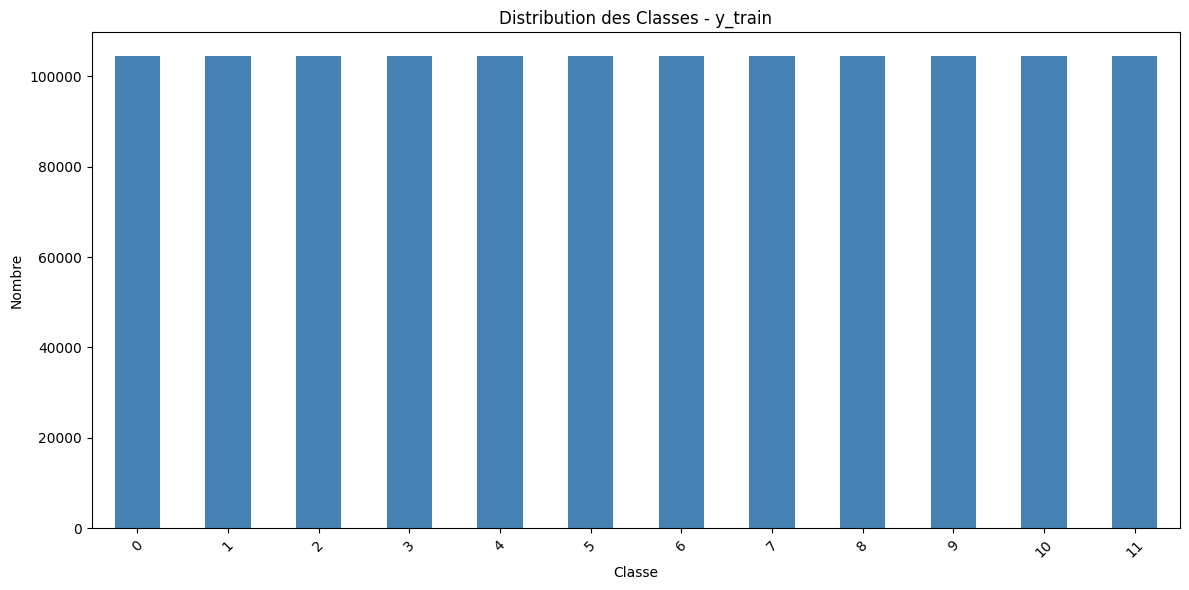

    X_train : (1253736, 31)


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
plt.figure(figsize=(12, 6))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution des Classes - y_train')
plt.xlabel('Classe')
plt.ylabel('Nombre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"    X_train : {X_train.shape}")

### ⚖️ RÉÉQUILIBRAGE DES CLASSES AVEC RandomUnderSampler  (pour réduire les classes majoritaires)

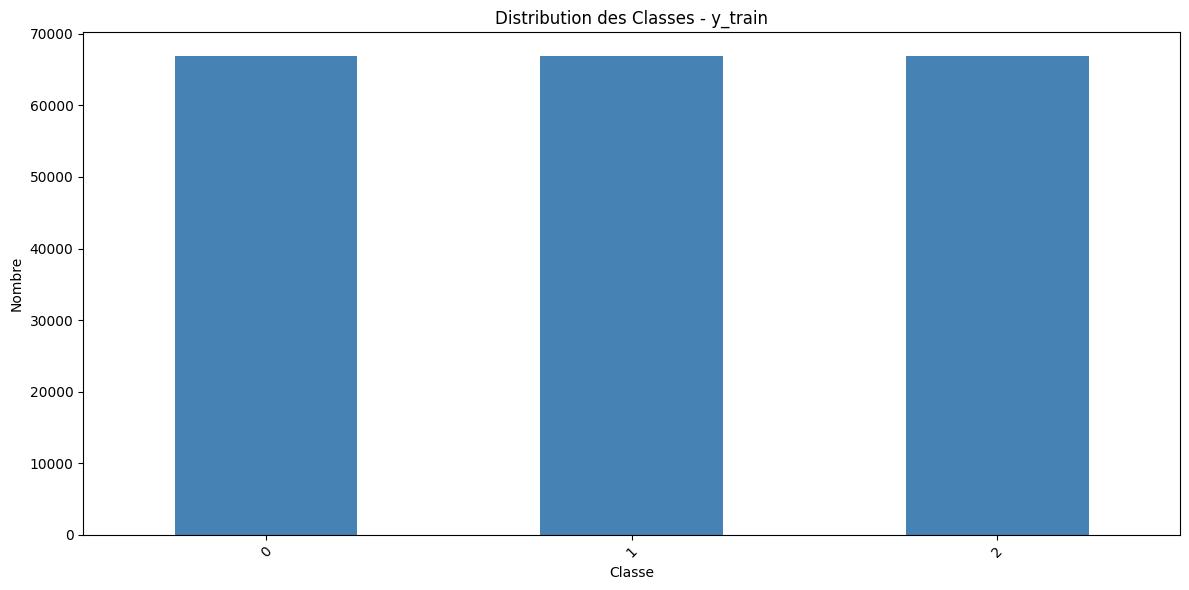

In [57]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
X_train, y_train = undersampler.fit_resample(X_train, y_train)

plt.figure(figsize=(12, 6))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution des Classes - y_train')
plt.xlabel('Classe')
plt.ylabel('Nombre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### reentrainement (RandomUnderSampler)

 Modèle : Random Forest
 Temps d'entraînement : 35.09 s

 Performances :
   Accuracy  : 0.9881
   Precision : 0.9882
   Recall    : 0.9881
   F1 Score  : 0.9881
   ROC AUC   : 0.9990

 Rapport de classification :
                     precision    recall  f1-score   support

ATTACK_EXPLOITATION       0.98      0.99      0.98     70926
  ATTACK_REFLECTION       0.99      0.99      0.99    137120
             BENIGN       0.99      1.00      1.00     18929

           accuracy                           0.99    226975
          macro avg       0.99      0.99      0.99    226975
       weighted avg       0.99      0.99      0.99    226975

 Modèle : XGBoost
 Temps d'entraînement : 11.09 s

 Performances :
   Accuracy  : 0.9892
   Precision : 0.9893
   Recall    : 0.9892
   F1 Score  : 0.9892
   ROC AUC   : 0.9997

 Rapport de classification :
                     precision    recall  f1-score   support

ATTACK_EXPLOITATION       0.97      0.99      0.98     70926
  ATTACK_REFLECTION       1

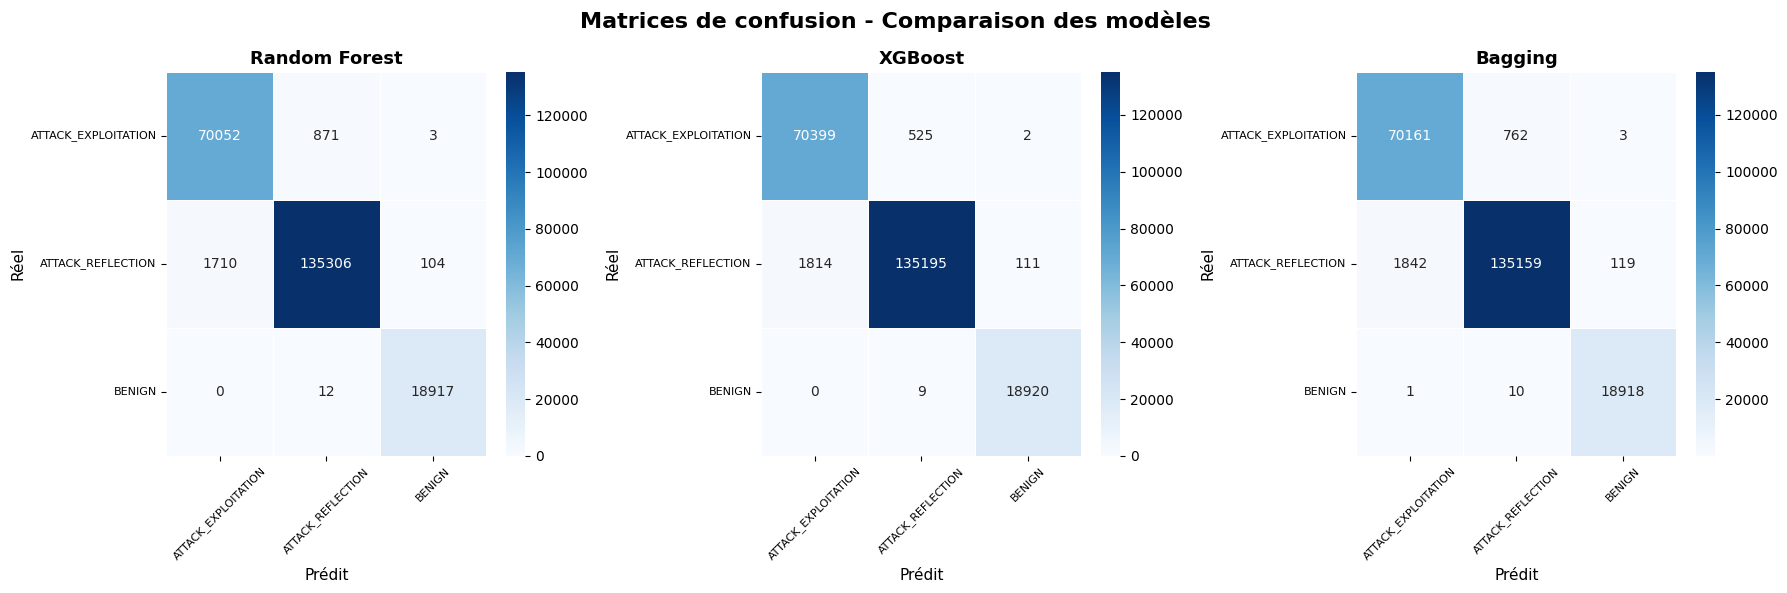

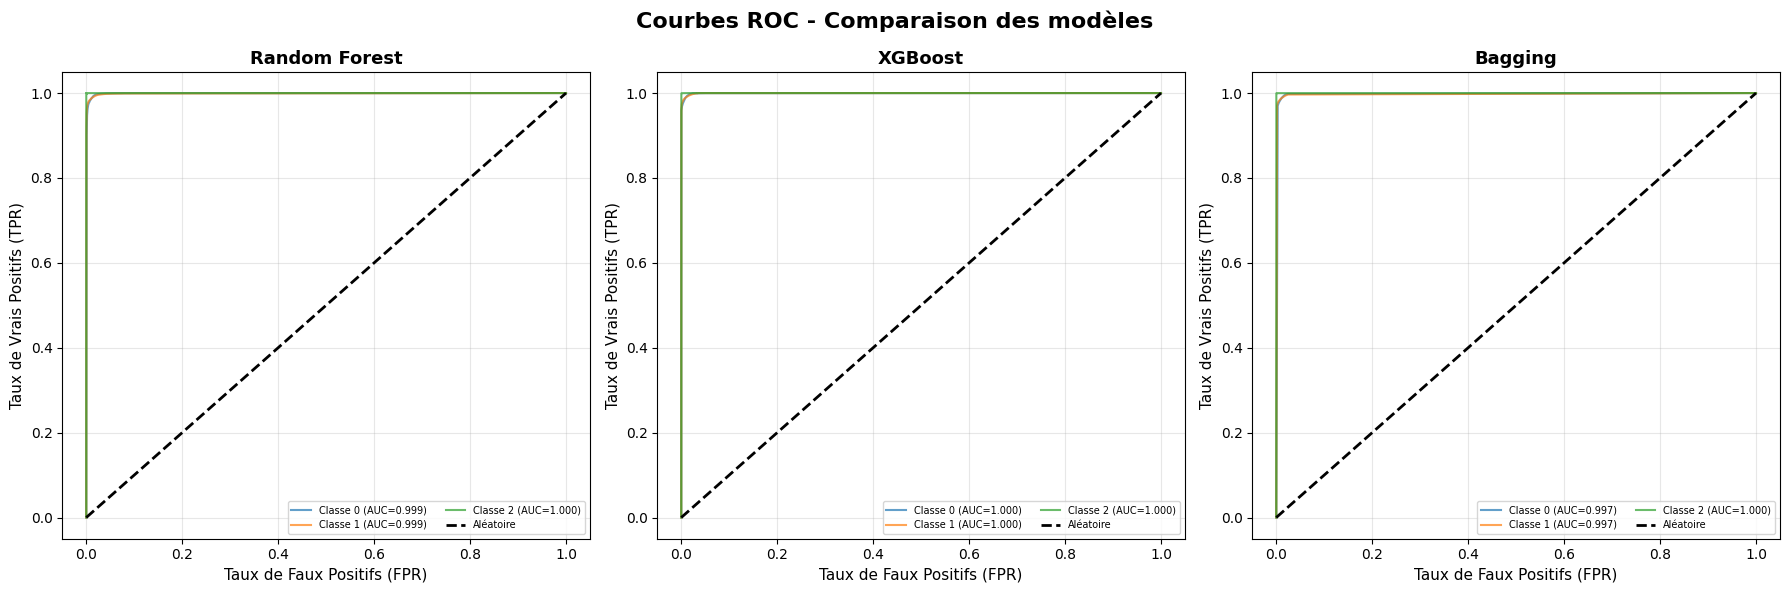

,Modèle,Accuracy,Precision,Recall,F1 Score,ROC AUC,Temps (s)
0,Random Forest,0.988104,0.988168,0.988104,0.988118,0.999046,35.090000
1,XGBoost,0.989157,0.989278,0.989157,0.989177,0.999739,11.090000
2,Bagging,0.987941,0.988036,0.987941,0.987959,0.997464,18.310000



 Classement par Accuracy :


In [58]:
import joblib
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from xgboost import XGBClassifier


def train_models(X_train, y_train, X_test, y_test, class_names):


    # Définition des modèles
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
        'Bagging': BaggingClassifier(estimator=DecisionTreeClassifier(),
                                     n_estimators=10, random_state=42)
    }

    results = {}
    summary = []

    # Dictionnaires pour stocker les données de visualisation
    confusion_matrices = {}
    probas = {}
    y_preds = {}

    # Entraînement et évaluation pour chaque modèle
    for name, model in models.items():
        print(f" Modèle : {name}")


        # Entraînement
        start = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - start
        print(f" Temps d'entraînement : {elapsed:.2f} s")

        # Prédictions
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        # Métriques
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # ROC AUC (multiclasse)
        n_classes = len(np.unique(y_train))
        y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
        roc_auc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')

        print(f"\n Performances :")
        print(f"   Accuracy  : {acc:.4f}")
        print(f"   Precision : {prec:.4f}")
        print(f"   Recall    : {rec:.4f}")
        print(f"   F1 Score  : {f1:.4f}")
        print(f"   ROC AUC   : {roc_auc:.4f}")
        print("\n Rapport de classification :")
        print(classification_report(y_test, y_pred, target_names=class_names))

        # Stockage pour les visualisations
        confusion_matrices[name] = confusion_matrix(y_test, y_pred)
        probas[name] = y_proba
        y_preds[name] = y_pred

        # Sauvegarde des résultats
        results[name] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'training_time': elapsed,
            'model': model,
            'y_pred': y_pred,
            'y_proba': y_proba
        }

        summary.append({
            'Modèle': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': roc_auc,
            "Temps (s)": round(elapsed, 2)
        })

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, (name, cm) in enumerate(confusion_matrices.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=axes[idx], linewidths=0.5)
        axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
        axes[idx].set_xlabel('Prédit', fontsize=11)
        axes[idx].set_ylabel('Réel', fontsize=11)
        axes[idx].tick_params(axis='x', rotation=45, labelsize=8)
        axes[idx].tick_params(axis='y', rotation=0, labelsize=8)

    plt.suptitle('Matrices de confusion - Comparaison des modèles', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    #  AFFICHAGE DES COURBES ROC
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    n_classes = len(np.unique(y_train))
    y_test_bin = label_binarize(y_test, classes=np.unique(y_train))

    for idx, (name, y_proba) in enumerate(probas.items()):
        ax = axes[idx]
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
            ax.plot(fpr, tpr, label=f'Classe {i} (AUC={auc:.3f})', alpha=0.7, linewidth=1.5)

        ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire', linewidth=2)
        ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
        ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
        ax.set_title(f'{name}', fontsize=13, fontweight='bold')
        ax.legend(loc='lower right', fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Courbes ROC - Comparaison des modèles', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # TABLEAU RÉCAPITULATIF
    df_summary = pd.DataFrame(summary)
    try:
        styled_df = df_summary.style.background_gradient(cmap='Blues',
              subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'])
        display(styled_df)
    except NameError:
        print(df_summary.to_string(index=False))

    print("\n Classement par Accuracy :")
    sorted_df = df_summary.sort_values('Accuracy', ascending=False)

    return results



# Class names
class_names = ['ATTACK_EXPLOITATION', 'ATTACK_REFLECTION', 'BENIGN']

results = train_models(X_train, y_train, X_test, y_test, class_names)

### OPTIMISATION RandomizedSearchCV


In [ ]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from xgboost import XGBClassifier


#  RANDOM FOREST
rf_param_dist = {
    'n_estimators': randint(150, 350),
    'max_depth': [15, 20, 25, None],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("\n Random Forest")
print("Meilleurs paramètres :", rf_search.best_params_)
print("Meilleur F1 :", rf_search.best_score_)


# XGBOOST

xgb_param_dist = {
    'n_estimators': randint(200, 400),
    'max_depth': randint(4, 10),
    'learning_rate': uniform(0.05, 0.2),
    'subsample': uniform(0.7, 0.25),
    'colsample_bytree': uniform(0.6, 0.3),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 2.0)
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_distributions=xgb_param_dist,
    n_iter=15,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("\n XGBoost")
print("Meilleurs paramètres :", xgb_search.best_params_)
print("Meilleur F1 :", xgb_search.best_score_)


# 3. BAGGING

bagging_param_dist = {
    'n_estimators': randint(20, 60),
    'max_samples': uniform(0.6, 0.35),
    'max_features': uniform(0.6, 0.35),
    'bootstrap': [True, False],
    'estimator__max_depth': [8, 10, 15, None],
    'estimator__min_samples_split': randint(2, 8),
    'estimator__min_samples_leaf': randint(1, 5)
}

bagging_search = RandomizedSearchCV(
    estimator=BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=bagging_param_dist,
    n_iter=15,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

bagging_search.fit(X_train, y_train)

print("\n Bagging")
print("Meilleurs paramètres :", bagging_search.best_params_)
print("Meilleur F1 :", bagging_search.best_score_)


print(f"Random Forest : {rf_search.best_score_:.4f}")
print(f"XGBoost       : {xgb_search.best_score_:.4f}")
print(f"Bagging       : {bagging_search.best_score_:.4f}")

 Modèle : Random Forest
 Temps d'entraînement : 292.47 s

 Performances :
   Accuracy  : 0.9105
   Precision : 0.9101
   Recall    : 0.9105
   F1 Score  : 0.9102
   ROC AUC   : 0.9916

 Rapport de classification :
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     18929
         DNS       0.68      0.66      0.67     12643
        LDAP       0.56      0.56      0.56      7369
       MSSQL       0.98      0.98      0.98     14423
         NTP       0.98      0.99      0.99     29979
     NetBIOS       0.75      0.75      0.75      4940
        SNMP       0.76      0.78      0.77     11555
        SSDP       0.99      0.99      0.99     27115
         Syn       1.00      1.00      1.00     26553
        TFTP       0.97      0.97      0.97     29096
         UDP       0.86      0.90      0.88     26528
      UDPLag       0.80      0.75      0.78     17845

    accuracy                           0.91    226975
   macro avg       0.86     

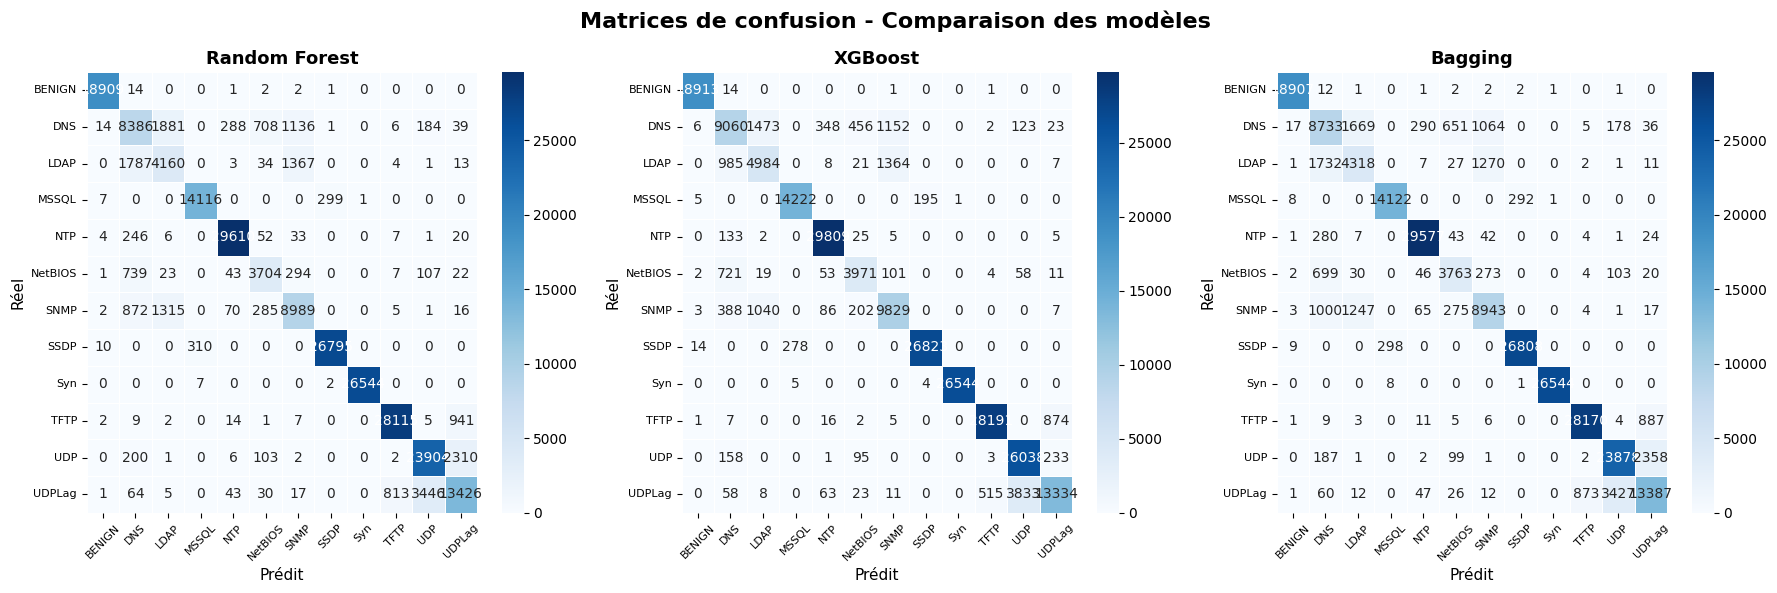

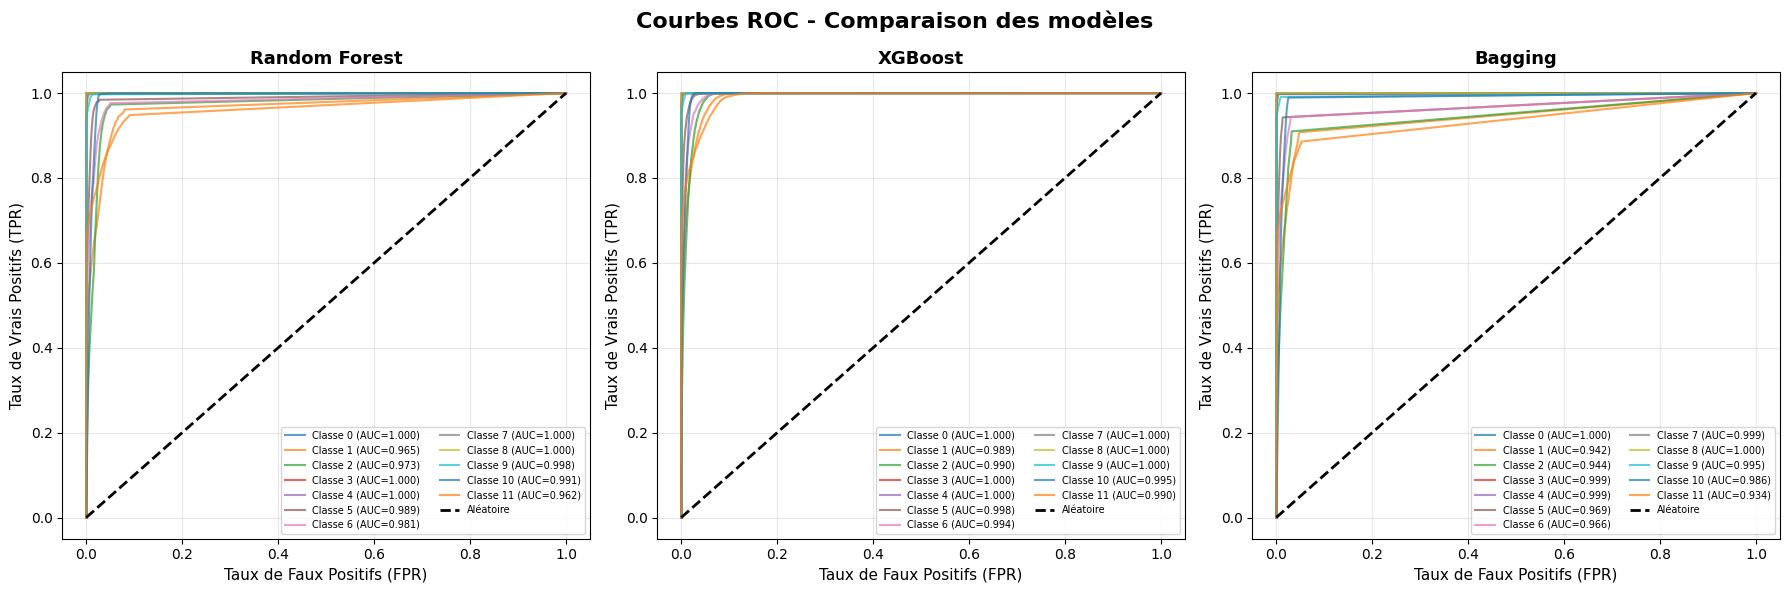

,Modèle,Accuracy,Precision,Recall,F1 Score,ROC AUC,Temps (s)
0,Random Forest,0.910488,0.910089,0.910488,0.910173,0.991640,292.470000
1,XGBoost,0.932781,0.933602,0.932781,0.931900,0.997322,147.240000
2,Bagging,0.912656,0.912272,0.912656,0.912360,0.984655,96.480000



 Classement par Accuracy :


In [ ]:
import joblib
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from xgboost import XGBClassifier


def train_models(X_train, y_train, X_test, y_test, class_names):


    # Définition des modèles
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
        'Bagging': BaggingClassifier(estimator=DecisionTreeClassifier(),
                                     n_estimators=10, random_state=42)
    }

    results = {}
    summary = []

    # Dictionnaires pour stocker les données de visualisation
    confusion_matrices = {}
    probas = {}
    y_preds = {}

    # Entraînement et évaluation pour chaque modèle
    for name, model in models.items():
        print(f" Modèle : {name}")


        # Entraînement
        start = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - start
        print(f" Temps d'entraînement : {elapsed:.2f} s")

        # Prédictions
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        # Métriques
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # ROC AUC (multiclasse)
        n_classes = len(np.unique(y_train))
        y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
        roc_auc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')

        print(f"\n Performances :")
        print(f"   Accuracy  : {acc:.4f}")
        print(f"   Precision : {prec:.4f}")
        print(f"   Recall    : {rec:.4f}")
        print(f"   F1 Score  : {f1:.4f}")
        print(f"   ROC AUC   : {roc_auc:.4f}")
        print("\n Rapport de classification :")
        print(classification_report(y_test, y_pred, target_names=class_names))

        # Stockage pour les visualisations
        confusion_matrices[name] = confusion_matrix(y_test, y_pred)
        probas[name] = y_proba
        y_preds[name] = y_pred

        # Sauvegarde des résultats
        results[name] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'training_time': elapsed,
            'model': model,
            'y_pred': y_pred,
            'y_proba': y_proba
        }

        summary.append({
            'Modèle': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': roc_auc,
            "Temps (s)": round(elapsed, 2)
        })

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, (name, cm) in enumerate(confusion_matrices.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=axes[idx], linewidths=0.5)
        axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
        axes[idx].set_xlabel('Prédit', fontsize=11)
        axes[idx].set_ylabel('Réel', fontsize=11)
        axes[idx].tick_params(axis='x', rotation=45, labelsize=8)
        axes[idx].tick_params(axis='y', rotation=0, labelsize=8)

    plt.suptitle('Matrices de confusion - Comparaison des modèles', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    #  AFFICHAGE DES COURBES ROC
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    n_classes = len(np.unique(y_train))
    y_test_bin = label_binarize(y_test, classes=np.unique(y_train))

    for idx, (name, y_proba) in enumerate(probas.items()):
        ax = axes[idx]
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
            ax.plot(fpr, tpr, label=f'Classe {i} (AUC={auc:.3f})', alpha=0.7, linewidth=1.5)

        ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire', linewidth=2)
        ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
        ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
        ax.set_title(f'{name}', fontsize=13, fontweight='bold')
        ax.legend(loc='lower right', fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Courbes ROC - Comparaison des modèles', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # TABLEAU RÉCAPITULATIF
    df_summary = pd.DataFrame(summary)
    try:
        styled_df = df_summary.style.background_gradient(cmap='Blues',
              subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'])
        display(styled_df)
    except NameError:
        print(df_summary.to_string(index=False))

    print("\n Classement par Accuracy :")
    sorted_df = df_summary.sort_values('Accuracy', ascending=False)

    return results


class_names = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS',
               'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag']

results = train_models(X_train, y_train, X_test, y_test, class_names)

In [ ]:
mmmmmmmmmmmmmmmmmmmmn

In [ ]:
meilleur_idx = scores['Accuracy'].idxmax()
meilleur_nom = scores.loc[meilleur_idx, 'Modèle']
meilleur_modele = modeles[meilleur_nom]

print(f"\n Meilleur modèle : {meilleur_nom}")
print(f"   Accuracy sur validation : {scores.loc[meilleur_idx, 'Accuracy']:.4f}")

y_pred = meilleur_modele.predict(X_test)
y_proba = meilleur_modele.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n Performances sur l'ensemble de test :")
print(f"  {'Accuracy  :':<15} {acc:.4f} ({acc*100:.2f}%)")
print(f"  {'Precision :':<15} {prec:.4f} ({prec*100:.2f}%)")
print(f"  {'Recall    :':<15} {rec:.4f} ({rec*100:.2f}%)")
print(f"  {'F1-Score  :':<15} {f1:.4f} ({f1*100:.2f}%)")

class_names = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS',
               'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 10})
plt.title(f'Matrice de Confusion - {meilleur_nom}', fontsize=16, fontweight='bold')
plt.xlabel('Prédictions', fontsize=14)
plt.ylabel('Réel', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(f'matrice_confusion_{meilleur_nom}.png', dpi=300, bbox_inches='tight')
plt.show()

print("="*70)
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


In [ ]:
# Prendre la 10ème ligne (index 9)
X_sample = X_test[9:10]  # Index 9 = 10ème ligne
y_sample = y_test[9:10]

# Prédire
y_pred_sample = meilleur_modele.predict(X_sample)

# Afficher le résultat
print(f"Réel : {y_sample[0]}")
print(f"Prédit : {y_pred_sample[0]}")
print(f"Correct : {y_sample[0] == y_pred_sample[0]}")

In [ ]:
# Récupérer les noms des colonnes
feature_names = train_df.drop('Label', axis=1).columns

X_sample = X_test[9:10]
y_sample = y_test[9:10]
y_pred_sample = meilleur_modele.predict(X_sample)

print("\n📊 10ème ligne - Variables :")
for name, value in zip(feature_names, X_sample[0]):
    print(f"  {name}: {value:.8f}" if isinstance(value, float) else f"  {name}: {value}")

class_names = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS',
               'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag']
print(f"\n🎯 Réel: {class_names[y_sample[0]]} | Prédit: {class_names[y_pred_sample[0]]}")

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



# Nombre de caractéristiques
n_features = X_train.shape[1]
print(f"\n  📊 Nombre de caractéristiques : {n_features}")

# Normalisation (Min-Max Scaler)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# Encodage des labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# Nombre de classes
n_classes = len(label_encoder.classes_)
print(f"  Nombre de classes : {n_classes}")
print(f"  Classes : {label_encoder.classes_}")

# One-hot encoding
y_train_categorical = tf.keras.utils.to_categorical(y_train_encoded, num_classes=n_classes)
y_val_categorical = tf.keras.utils.to_categorical(y_val_encoded, num_classes=n_classes)
y_test_categorical = tf.keras.utils.to_categorical(y_test_encoded, num_classes=n_classes)



def build_cybernet_model(n_features, n_classes, binary=False):


    # Couche d'entrée
    inputs = layers.Input(shape=(n_features,))

    # Reshape pour LSTM et Conv1D
    x = layers.Reshape((n_features, 1))(inputs)

    # Bloc 1: LSTM + Conv1D
    lstm1 = layers.LSTM(n_features, return_sequences=True)(x)
    lstm1 = layers.LeakyReLU(alpha=0.01)(lstm1)

    conv1 = layers.Conv1D(filters=64, kernel_size=3, padding='same')(x)
    conv1 = layers.LeakyReLU(alpha=0.01)(conv1)
    conv1_adjusted = layers.Conv1D(filters=n_features, kernel_size=1, padding='same')(conv1)

    add1 = layers.Add()([lstm1, conv1_adjusted])
    pool1 = layers.MaxPooling1D(pool_size=2)(add1)

    # Bloc 2: LSTM + Conv1D
    lstm2 = layers.LSTM(39, return_sequences=True)(pool1)
    lstm2 = layers.LeakyReLU(alpha=0.01)(lstm2)

    conv2 = layers.Conv1D(filters=128, kernel_size=3, padding='same')(pool1)
    conv2 = layers.LeakyReLU(alpha=0.01)(conv2)
    conv2_adjusted = layers.Conv1D(filters=39, kernel_size=1, padding='same')(conv2)

    add2 = layers.Add()([lstm2, conv2_adjusted])
    pool2 = layers.MaxPooling1D(pool_size=2)(add2)

    # Flatten
    flatten1 = layers.Flatten()(pool2)

    # Bloc 3: Dense + Dense
    dense1 = layers.Dense(256)(flatten1)
    dense1 = layers.LeakyReLU(alpha=0.01)(dense1)
    dense1_reshaped = layers.Reshape((256, 1))(dense1)

    dense2 = layers.Dense(128)(flatten1)
    dense2 = layers.LeakyReLU(alpha=0.01)(dense2)
    dense2_padded = layers.ZeroPadding1D(padding=((0, 128)))(layers.Reshape((128, 1))(dense2))

    add3 = layers.Add()([dense1_reshaped, dense2_padded])
    pool3 = layers.MaxPooling1D(pool_size=2)(add3)

    # Bloc 4: Dense + Dense
    flatten2 = layers.Flatten()(pool3)

    dense3 = layers.Dense(512)(flatten2)
    dense3 = layers.LeakyReLU(alpha=0.01)(dense3)
    dense3_reshaped = layers.Reshape((512, 1))(dense3)

    dense4 = layers.Dense(256)(flatten2)
    dense4 = layers.LeakyReLU(alpha=0.01)(dense4)
    dense4_padded = layers.ZeroPadding1D(padding=((0, 256)))(layers.Reshape((256, 1))(dense4))

    add4 = layers.Add()([dense3_reshaped, dense4_padded])
    pool4 = layers.MaxPooling1D(pool_size=2)(add4)

    # Dropout
    dropout = layers.Dropout(0.2)(pool4)

    # Flatten final
    flatten_final = layers.Flatten()(dropout)

    # Couche de sortie
    if binary:
        outputs = layers.Dense(1, activation='sigmoid')(flatten_final)
    else:
        outputs = layers.Dense(n_classes, activation='softmax')(flatten_final)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# ============================================================
# 3. MODÈLE MULTICLASSE
# ============================================================
print("\n" + "="*70)
print(" 3. MODÈLE MULTICLASSE (12 classes)")
print("="*70)

model = build_cybernet_model(n_features, n_classes, binary=False)
model.summary()

# Paramètres
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 30

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n  ✅ Modèle multiclasse compilé")
print(f"    Optimizer : Adam (lr={LEARNING_RATE})")
print(f"    Loss : Categorical Crossentropy")
print(f"    Batch size : {BATCH_SIZE}")
print(f"    Epochs : {EPOCHS}")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_cybernet_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]



history = model.fit(
    X_train_scaled, y_train_categorical,
    validation_data=(X_val_scaled, y_val_categorical),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


print("\n" + "="*70)
print(" 5. ÉVALUATION MULTICLASSE")
print("="*70)

y_pred_proba = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_categorical, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\n   Performances multiclasse :")
print(f"    Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"    Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"    Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"    F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

print("\n   Classification Report :")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, digits=4))

# Matrice de confusion multiclasse
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matrice de Confusion - Modèle Cybernet Multiclasse', fontsize=16, fontweight='bold')
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérités', fontsize=12)
plt.tight_layout()
plt.show()

# Courbes d'apprentissage multiclasse
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], 'b-o', label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], 'r-s', label='Val Accuracy', linewidth=2)
ax1.set_title('Accuracy - Modèle Cybernet Multiclasse', fontsize=14, fontweight='bold')
ax1.set_xlabel('Époques', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], 'b-o', label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
ax2.set_title('Loss - Modèle Cybernet Multiclasse', fontsize=14, fontweight='bold')
ax2.set_xlabel('Époques', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()



# Sauvegarder les modèles
model.save('cybernet_multiclass_model.h5')

# Sauvegarder le scaler et le label encoder
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print("\n    Modèles et préprocesseurs sauvegardés :")
print("    - cybernet_multiclass_model.h5")
print("    - cybernet_binary_model.h5")
print("    - scaler.pkl")
print("    - label_encoder.pkl")



print(f"""
      Entraînement du modèle Cybernet terminé !

      Performances du modèle multiclasse (12 classes) :
    - Accuracy  : {accuracy*100:.2f}%
    - Precision : {precision*100:.2f}%
    - Recall    : {recall*100:.2f}%
    - F1-Score  : {f1*100:.2f}%

      Performances du modèle binaire (2 classes) :
    - Accuracy  : {accuracy_bin*100:.2f}%
    - Precision : {precision_bin*100:.2f}%
    - Recall    : {recall_bin*100:.2f}%
    - F1-Score  : {f1_bin*100:.2f}%

     Fichiers sauvegardés :
    - cybernet_multiclass_model.h5
    - cybernet_binary_model.h5
    - scaler.pkl
    - label_encoder.pkl
    - confusion_matrix_multi.png
    - confusion_matrix_binary.png
    - learning_curves_multi.png
    - learning_curves_binary.png


""")


In [ ]:
# Labels binaires
y_train_binary = np.where(y_train_encoded == 0, 0, 1)
y_val_binary = np.where(y_val_encoded == 0, 0, 1)
y_test_binary = np.where(y_test_encoded == 0, 0, 1)

print(f"\n    Distribution binaire :")
print(f"    Train - BENIGN: {sum(y_train_binary == 0):,}, ATTACK: {sum(y_train_binary == 1):,}")
print(f"    Val   - BENIGN: {sum(y_val_binary == 0):,}, ATTACK: {sum(y_val_binary == 1):,}")
print(f"    Test  - BENIGN: {sum(y_test_binary == 0):,}, ATTACK: {sum(y_test_binary == 1):,}")


model_binary = build_cybernet_model(n_features, n_classes, binary=True)

model_binary.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\n   Modèle binaire compilé")
print(f"    Optimizer : Adam (lr={LEARNING_RATE})")
print(f"    Loss : Binary Crossentropy")
print(f"    Batch size : {BATCH_SIZE}")

history_binary = model_binary.fit(
    X_train_scaled, y_train_binary,
    validation_data=(X_val_scaled, y_val_binary),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

y_pred_binary = (model_binary.predict(X_test_scaled) > 0.5).astype(int)

accuracy_bin = accuracy_score(y_test_binary, y_pred_binary)
precision_bin = precision_score(y_test_binary, y_pred_binary)
recall_bin = recall_score(y_test_binary, y_pred_binary)
f1_bin = f1_score(y_test_binary, y_pred_binary)

print(f"\n   Performances binaires :")
print(f"    Accuracy  : {accuracy_bin:.4f} ({accuracy_bin*100:.2f}%)")
print(f"    Precision : {precision_bin:.4f} ({precision_bin*100:.2f}%)")
print(f"    Recall    : {recall_bin:.4f} ({recall_bin*100:.2f}%)")
print(f"    F1-Score  : {f1_bin:.4f} ({f1_bin*100:.2f}%)")

print("\n  Classification Report (Binaire) :")
print(classification_report(y_test_binary, y_pred_binary, target_names=['BENIGN', 'ATTACK'], digits=4))

# Matrice de confusion binaire
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)
tn, fp, fn, tp = cm_binary.ravel()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'],
            annot_kws={'size': 16})
plt.title('Matrice de Confusion - Modèle Cybernet Binaire', fontsize=16, fontweight='bold')
plt.xlabel('Prédictions', fontsize=14)
plt.ylabel('Vérités', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_binary.png', dpi=300)
plt.show()

print(" COURBES D'APPRENTISSAGE BINAIRES")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history_binary.history['accuracy'], 'b-o', label='Train Accuracy', linewidth=2)
ax1.plot(history_binary.history['val_accuracy'], 'r-s', label='Val Accuracy', linewidth=2)
ax1.set_title('Accuracy - Modèle Cybernet Binaire', fontsize=14, fontweight='bold')
ax1.set_xlabel('Époques', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.98, 1.0)

# Loss
ax2.plot(history_binary.history['loss'], 'b-o', label='Train Loss', linewidth=2)
ax2.plot(history_binary.history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
ax2.set_title('Loss - Modèle Cybernet Binaire', fontsize=14, fontweight='bold')
ax2.set_xlabel('Époques', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Exporter le meilleur modèle pour le déploiement

In [ ]:

# 7. Sauvegarder
import joblib
#joblib.dump(meilleur_modele, 'meilleur_modele.pkl')
#print(f"\n Modèle sauvegardé : meilleur_modele.pkl")

In [ ]:
#model.save('modele_cnn_ddos.h5')
#print(" Modèle CNN sauvegardé !")

In [ ]:
# 1. Récupérer les noms des colonnes
feature_names = train_df.drop('Label', axis=1).columns.tolist()

# 2. Convertir en DataFrames si nécessaire
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)
    #X_val = pd.DataFrame(X_val, columns=feature_names)
    X_test = pd.DataFrame(X_test, columns=feature_names)

# SELECTKBEST
selector = SelectKBest(f_classif, k=20)
selector.fit(X_train, y_train)
scores = selector.scores_
selected_indices = selector.get_support(indices=True)

df_kbest = pd.DataFrame({
    'Feature': feature_names,
    'Score': scores
}).sort_values('Score', ascending=False)

#  RANDOM FOREST
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# SelectKBest
top20_kbest_df = df_kbest.head(20)
axes[0].barh(top20_kbest_df['Feature'][::-1], top20_kbest_df['Score'][::-1], color='steelblue')
axes[0].set_title("SelectKBest - Top 20", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Score F")

# Random Forest
top20_rf_df = importance_df.head(20)
axes[1].barh(top20_rf_df['Feature'][::-1], top20_rf_df['Importance'][::-1], color='darkorange')
axes[1].set_title("Random Forest - Top 20", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()
seuil = 0.05
meilleures_features_rf = importance_df[importance_df["Importance"] >= seuil]["Feature"].tolist()
#X_train = X_train[meilleures_features_rf]
#X_val = X_val[meilleures_features_rf]
#X_test = X_test[meilleures_features_rf]